## Import

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [3]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [4]:
pre_path = "../../../../../../../"
physical_model = "PARSEC"
path_to_data = pre_path + "data/PARSEC/"
path_to_results = pre_path + "results/model_A_partial/default_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/default_models/"
tag = "scale_standard"
output_parameters = ['mass', 'radius']
categories_name = ["label"]

In [5]:
override = True
use_preds = False
save = True
show = True
scaler_name = "standard"

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading PARSEC dataframe from PARSEC_rescaled_iso_full_data.csv file...


,logAge,logTe,logg,label,metallicity,Mass,Rpol
0,5.00000,3.4744,2.965,0.0,-0.25,0.090,0.213783
1,5.00000,3.4752,2.963,0.0,-0.25,0.092,0.219060
2,5.00000,3.4780,2.956,0.0,-0.25,0.098,0.236789
3,5.00000,3.4789,2.954,0.0,-0.25,0.100,0.242293
4,5.00000,3.4819,2.950,0.0,-0.25,0.106,0.257918
...,...,...,...,...,...,...,...
681298,10.25002,3.4812,0.032,7.0,0.50,0.801,2.156549
681299,10.25002,3.4776,-0.004,7.0,0.50,0.801,2.175802
681300,10.25002,3.4742,-0.038,7.0,0.50,0.800,2.194514
681301,10.25002,3.4701,-0.077,7.0,0.50,0.800,2.215902


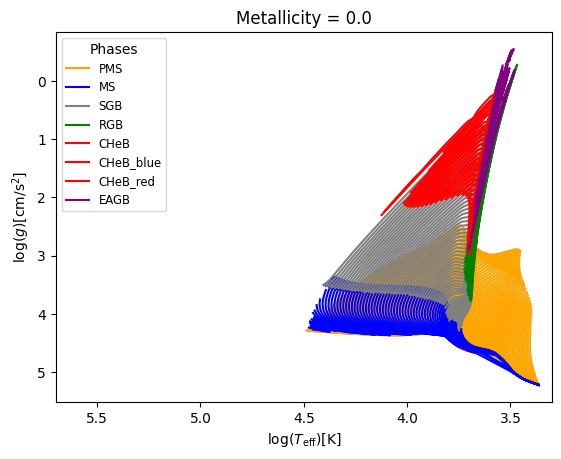

In [6]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['logAge', 'logTe', 'logg', 'label', 'metallicity', 'Mass', 'Rpol'], 
                              physical_model, rescale=True)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

,logAge,logTe,logg,label,metallicity,Mass,Rpol
0,5.60000,4.4269,4.356,1.0,-0.25,9.714,0.535041
1,5.65000,4.4266,4.355,1.0,-0.25,9.714,0.535800
2,5.70000,4.4263,4.353,1.0,-0.25,9.714,0.536558
3,5.75000,4.4061,4.358,1.0,-0.25,8.856,0.514282
4,5.75000,4.4260,4.352,1.0,-0.25,9.714,0.537441
...,...,...,...,...,...,...,...
321691,10.25002,3.6561,2.334,4.0,0.50,0.805,1.005181
321692,10.25002,3.6560,2.333,4.0,0.50,0.805,1.005609
321693,10.25002,3.6559,2.331,4.0,0.50,0.805,1.006466
321694,10.25002,3.6558,2.330,4.0,0.50,0.805,1.006894


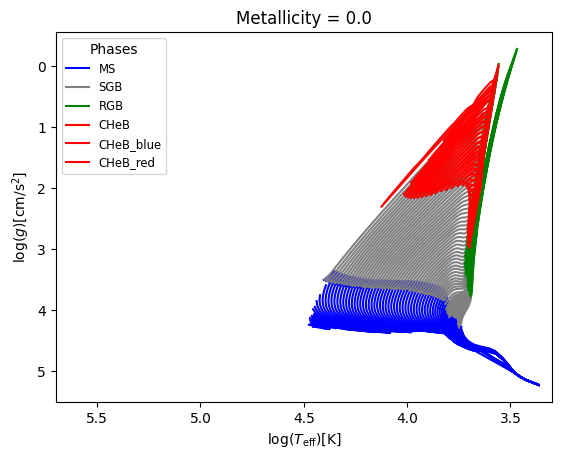

In [7]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'label':[1, 2, 3, 4, 5, 6]})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [8]:
print_all_uniques(phase_filtered_iso_df)

logAge  : Range : 5.3 - 10.25, Mean : 9.0428, Median : 9.3

logTe  : Range : 3.36 - 4.5177, Mean : 3.7779, Median : 3.721

logg  : Range : -0.38 - 5.345, Mean : 2.7607, Median : 2.486

Values in label column : 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.25, -2.5, -2.75, 0.0, 0.25, 0.5 

Mass  : Range : 0.09 - 13.952, Mean : 2.6725, Median : 1.428

Rpol  : Range : -0.98 - 2.8373, Mean : 0.9648, Median : 1.0158



In [9]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['logAge', 'logTe', 'logg', 'metallicity'], 
                               y_cols=['Mass', 'Rpol'], categories_cols=['label'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the Mass parameter : 0.09 - 13.943
Median value in train data for the Mass parameter: 1.427
Mean value in train data for the Mass parameter: 2.674483292715276

Range in train data for the Rpol parameter : -0.9763360818022064 - 2.8372727025023003
Median value in train data for the Rpol parameter: 1.015778756389041
Mean value in train data for the Rpol parameter: 0.9646120024510401

Testing set statistics:
Range in test data for the Mass parameter : 0.09 - 13.952
Median value in test data for the Mass parameter: 1.43
Mean value in test data for the Mass parameter: 2.6664658683974936

Range in test data for the Rpol parameter : -0.9763360818022064 - 2.831997677235896
Median value in test data for the Rpol parameter: 1.015778756389041
Mean value in test data for the Rpol parameter: 0.9652648999427869

(241272, 4) (80424, 4)
(241272, 2) (80424, 2)


## Model training

### Linear regression

In [10]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_standard train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.7140803707653718
  RMSE :  1.6260706065841861
  MAE :  1.3562018118192694
  MedAE :  1.2151522118099383
  CORR :  0.8773843227443293
  MAX_ER :  5.809022809395156
  Percentiles : 
    75th percentile :  1.9209920410790193
    90th percentile :  2.507425570053972
    95th percentile :  2.9477708333457215
    99th percentile :  4.134527222989049

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.8170987684749771
  RMSE :  1.4568068548856596
  MAE :  1.0807392493062709
  MedAE :  0.8784675623561693
  CORR :  0.9105157535025173
  MAX_ER :  5.5317449240506456
  Percentiles : 
    75th percentile :  1.1846194187047732
    90th percentile :  2.1507340911373043
    95th percentile :  3.42735553076353
    99th percentile :  4.8223047185811305

mas

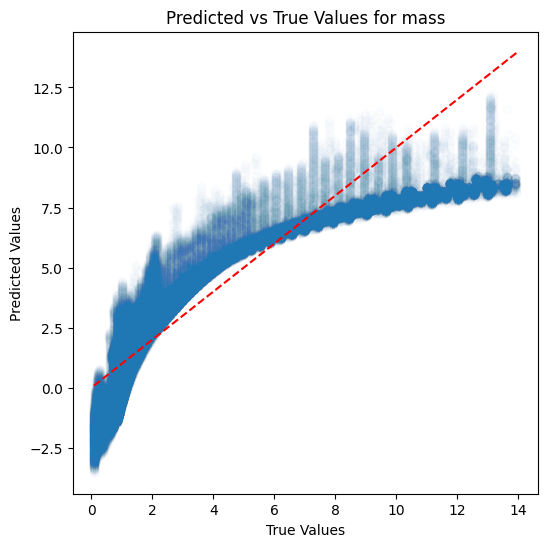

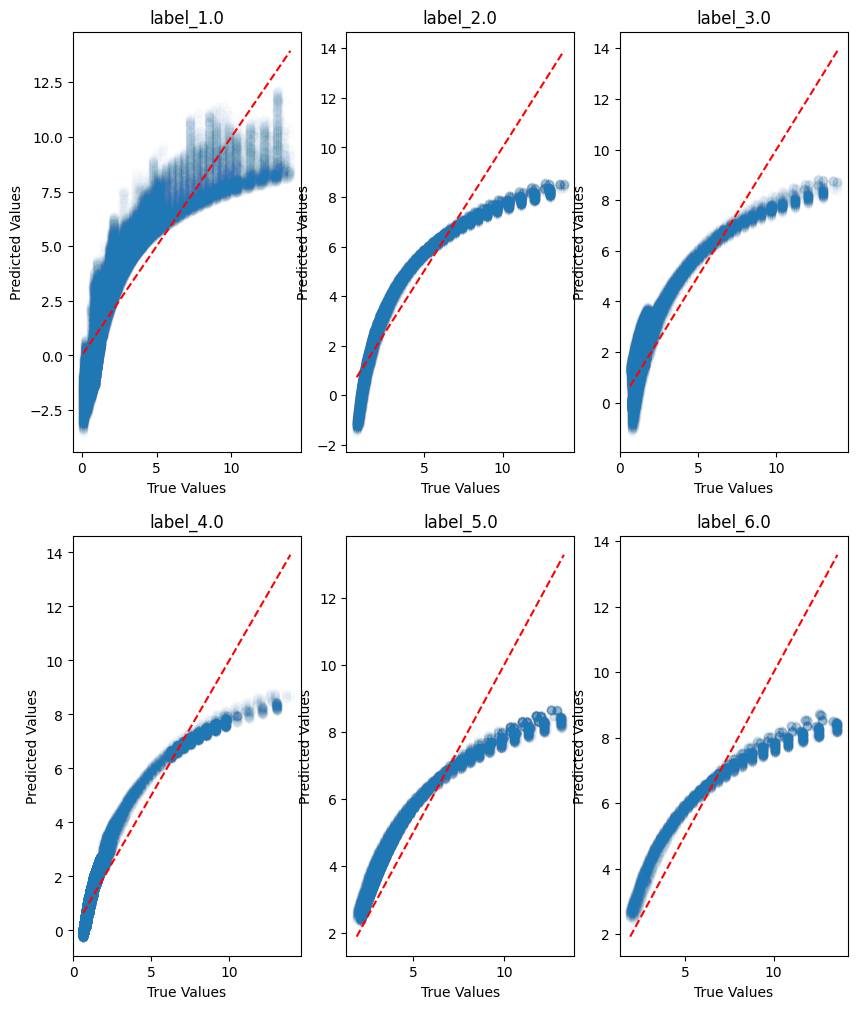

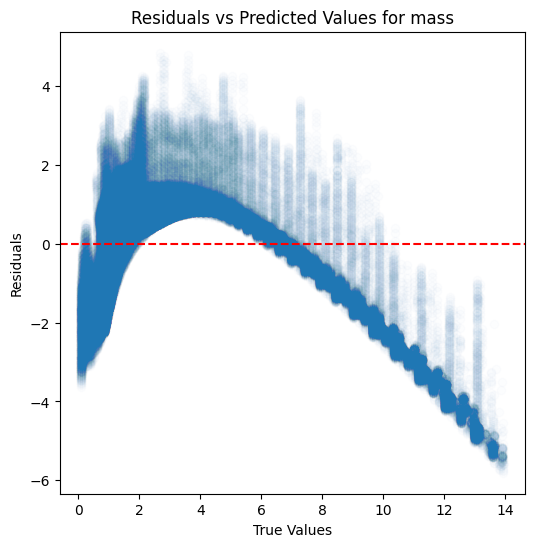

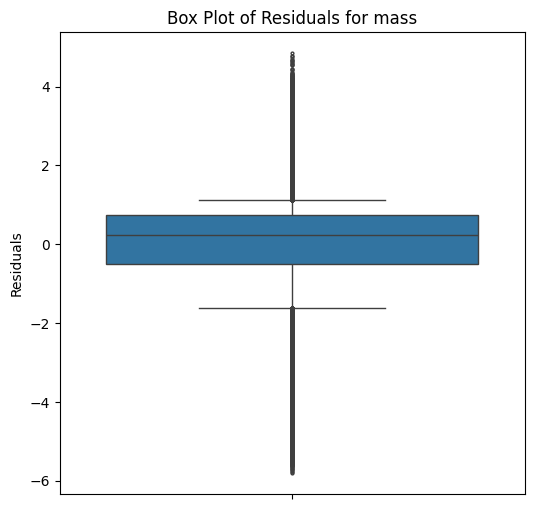

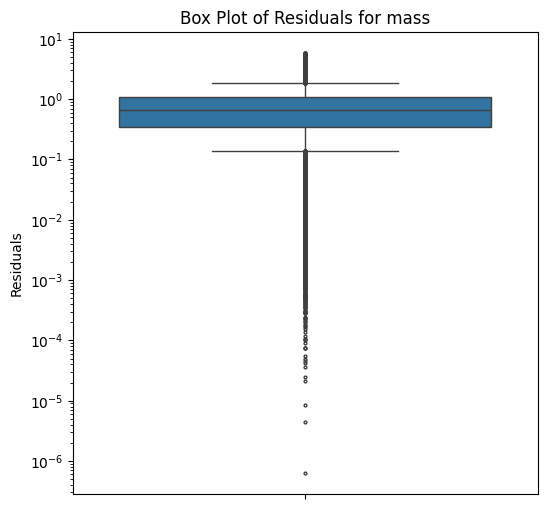

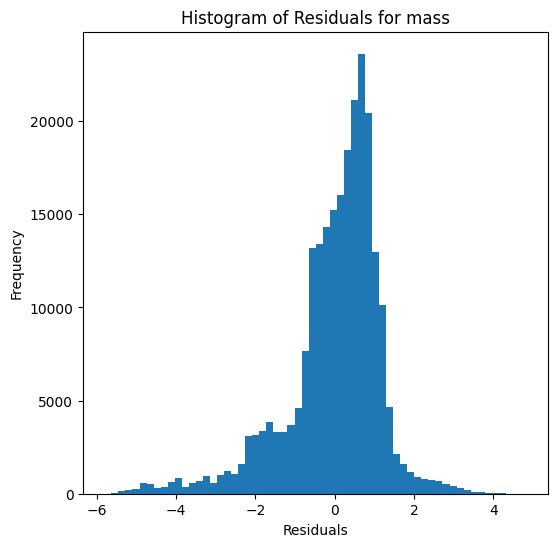

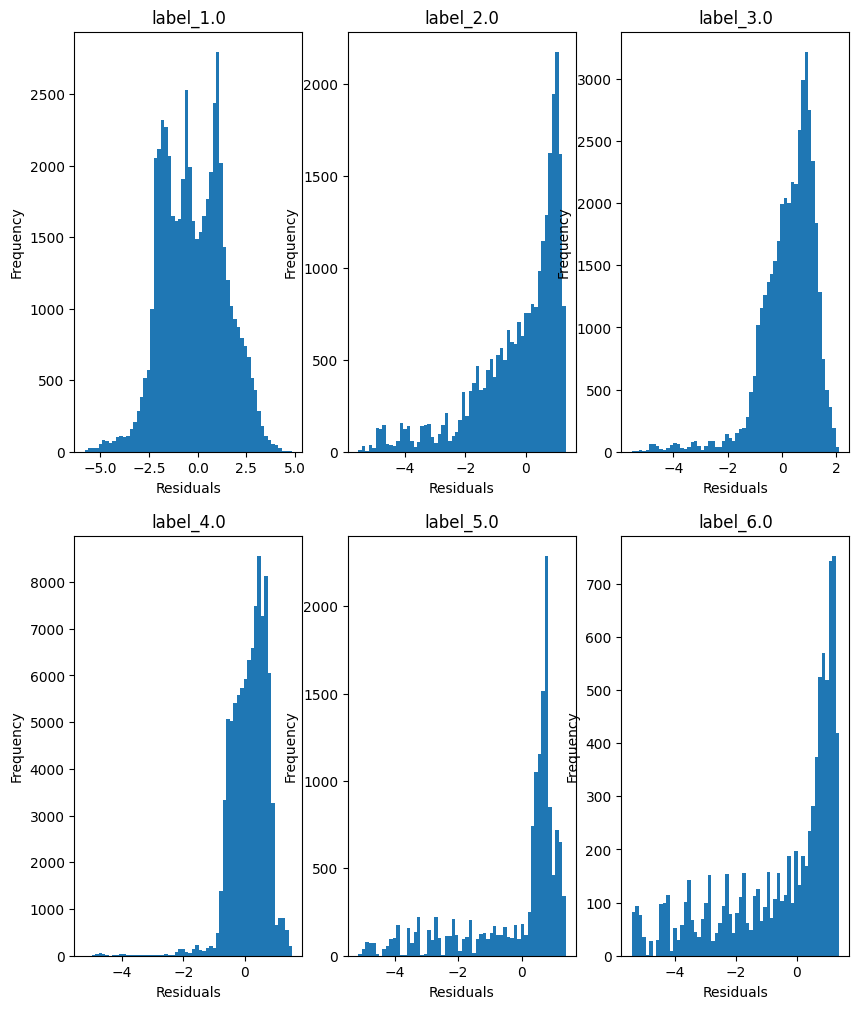

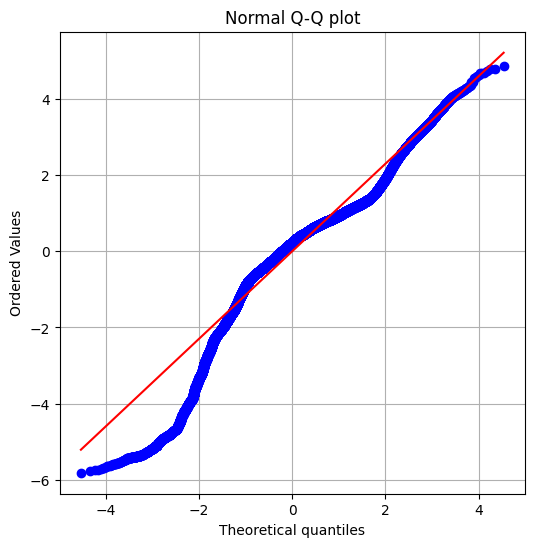

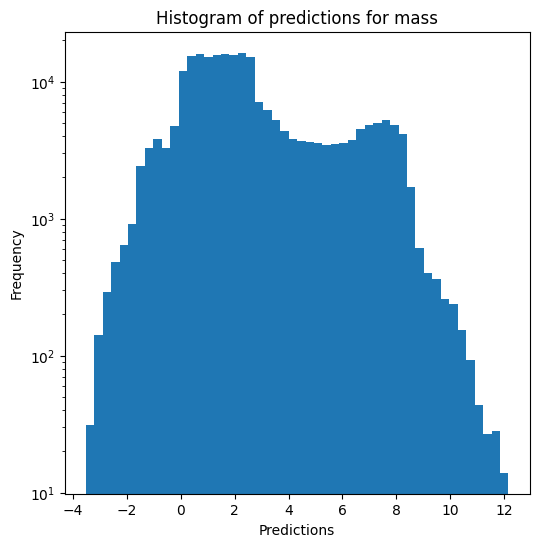

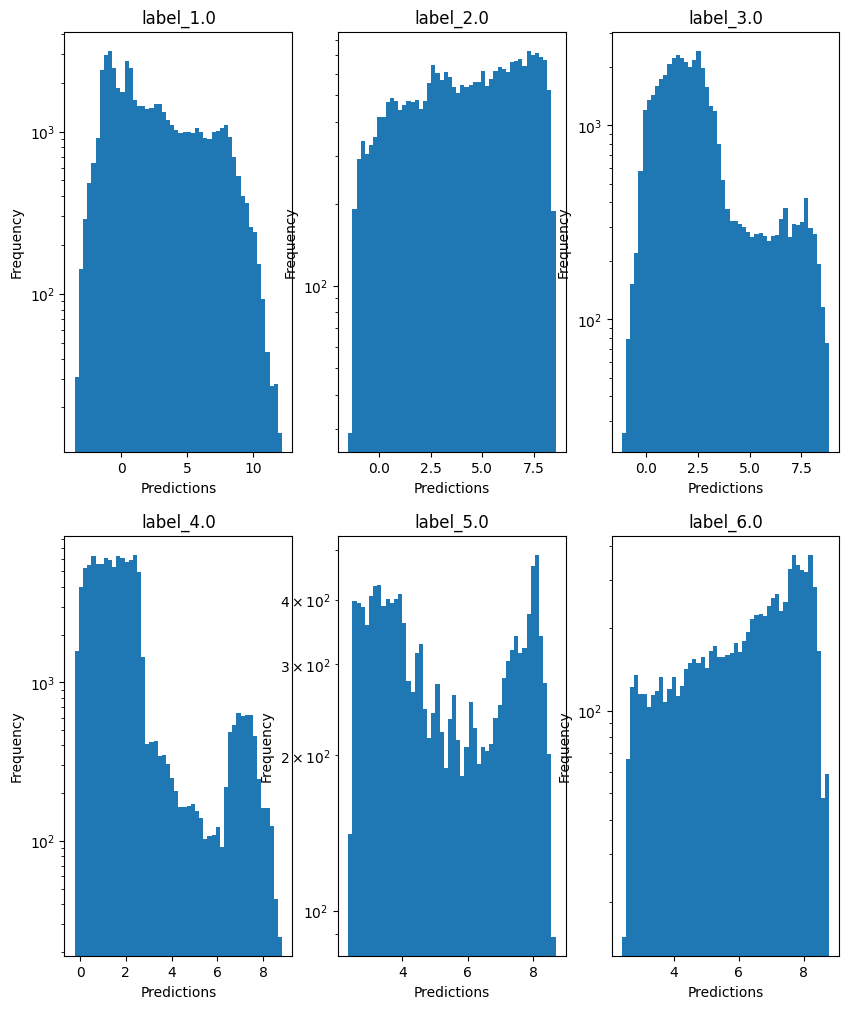

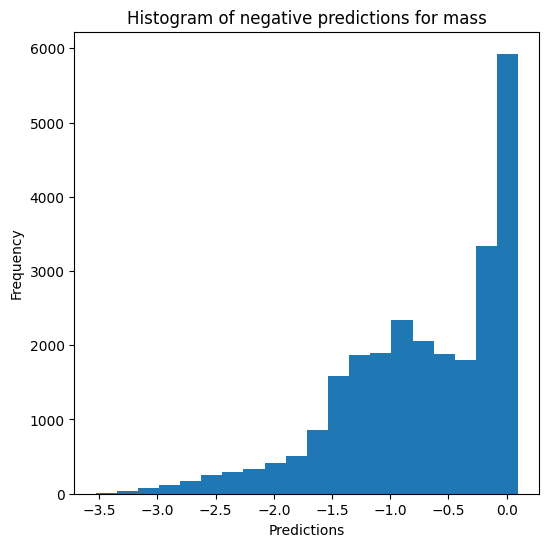


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9484107826824846
  RMSE :  0.0832858732502975
  MAE :  0.06347474231029802
  MedAE :  0.05315497875549401
  CORR :  0.973870221001157
  MAX_ER :  0.350667243496975
  Percentiles : 
    75th percentile :  0.08970545471742403
    90th percentile :  0.11906427683747581
    95th percentile :  0.16799917501829637
    99th percentile :  0.2684041042259843

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.997770016695508
  RMSE :  0.038903834702839604
  MAE :  0.03059082713625494
  MedAE :  0.02514257480641291
  CORR :  0.9991018210196537
  MAX_ER :  0.11589185744680722
  Percentiles : 
    75th percentile :  0.0443484303566786
    90th percentile :  0.06665784034104305
    95th percentile :  0.07914560411328349
    99th percentile :  0.09843326758110613

radius results for the label category

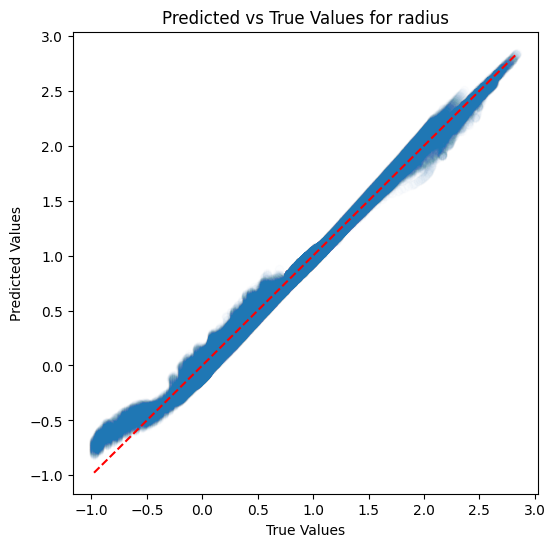

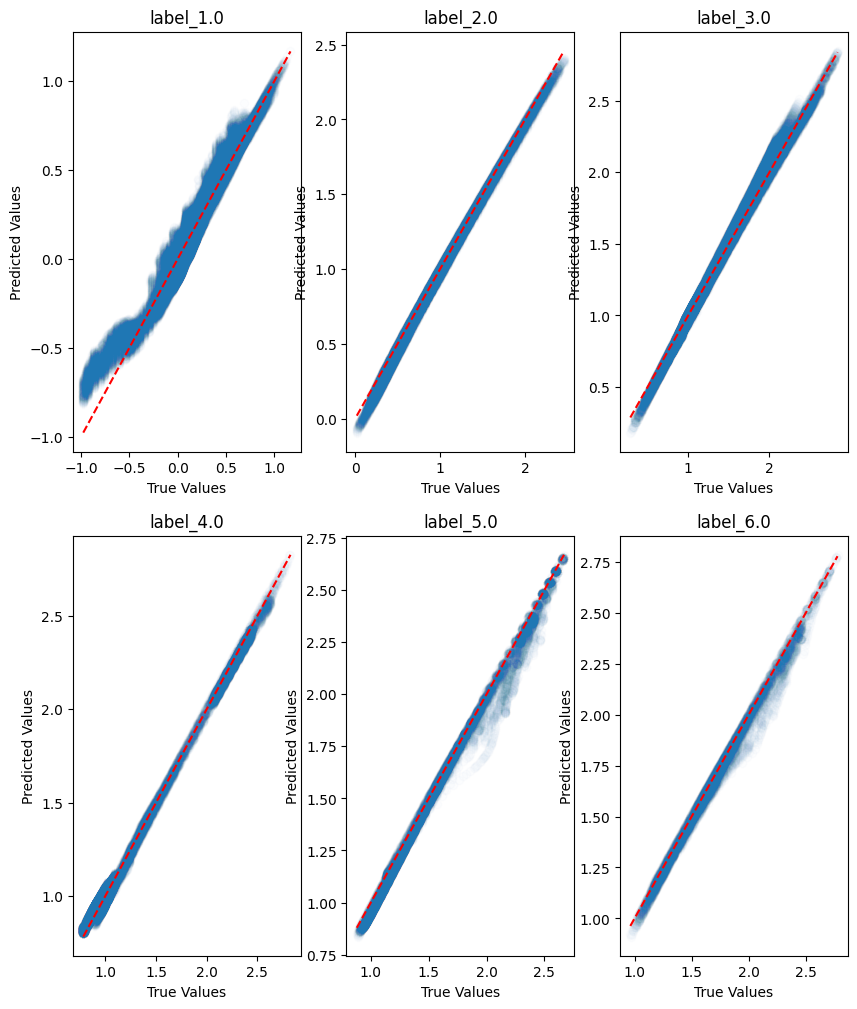

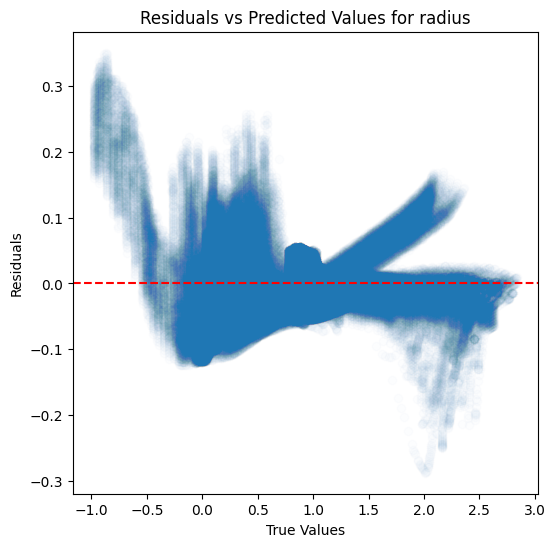

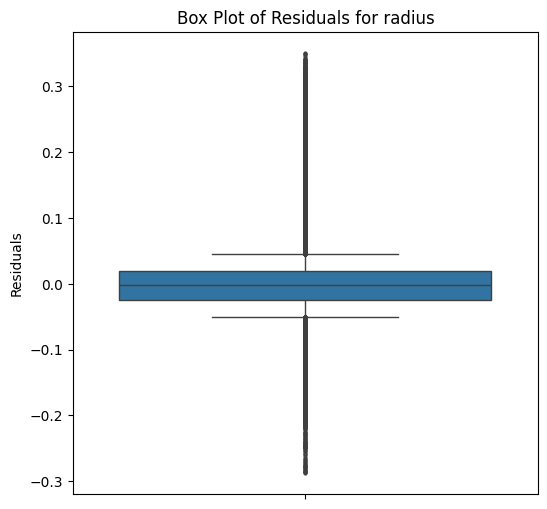

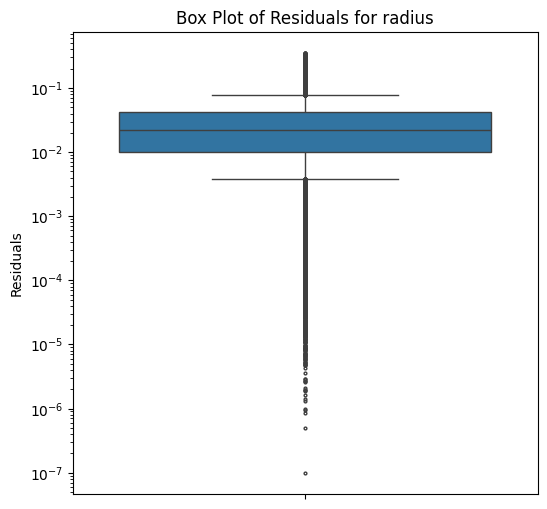

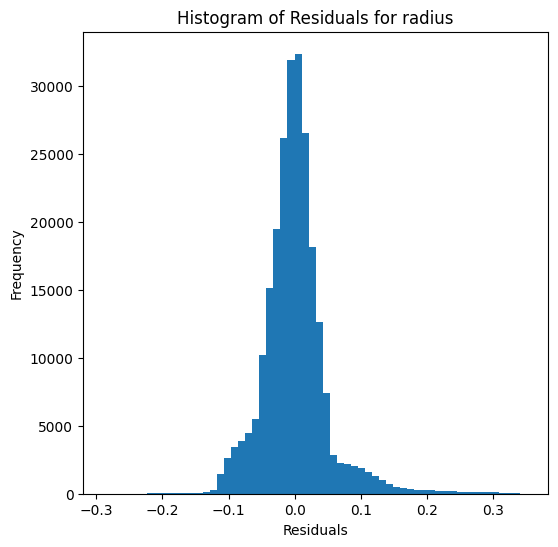

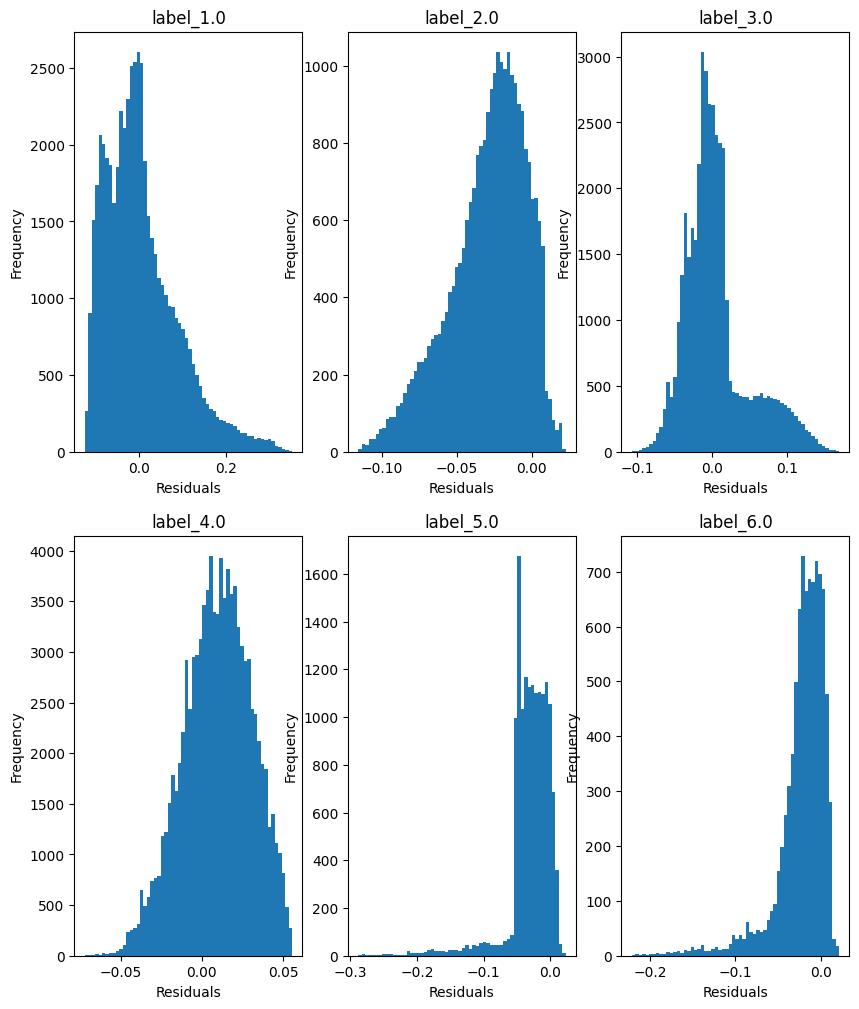

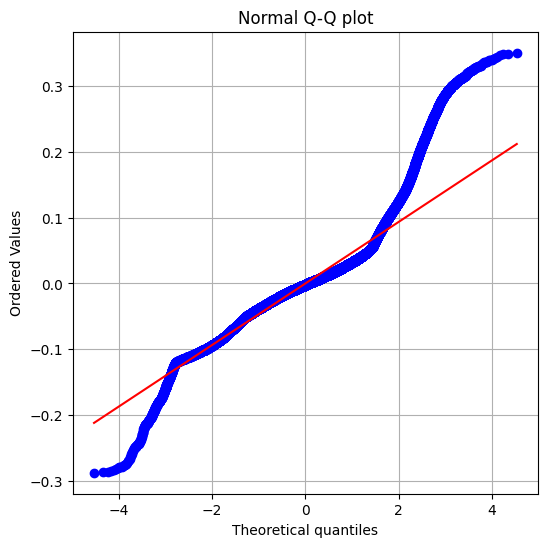

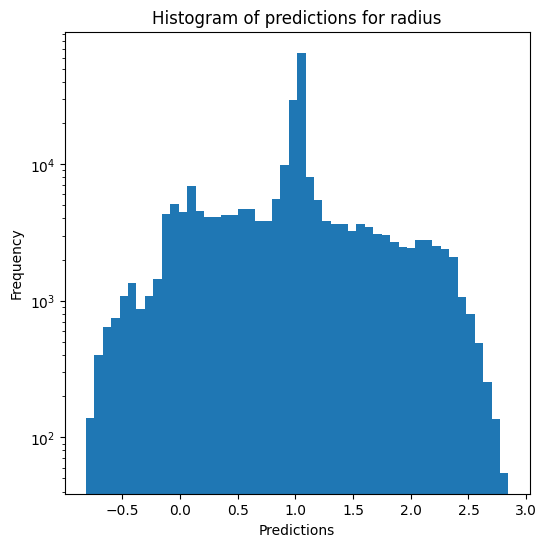

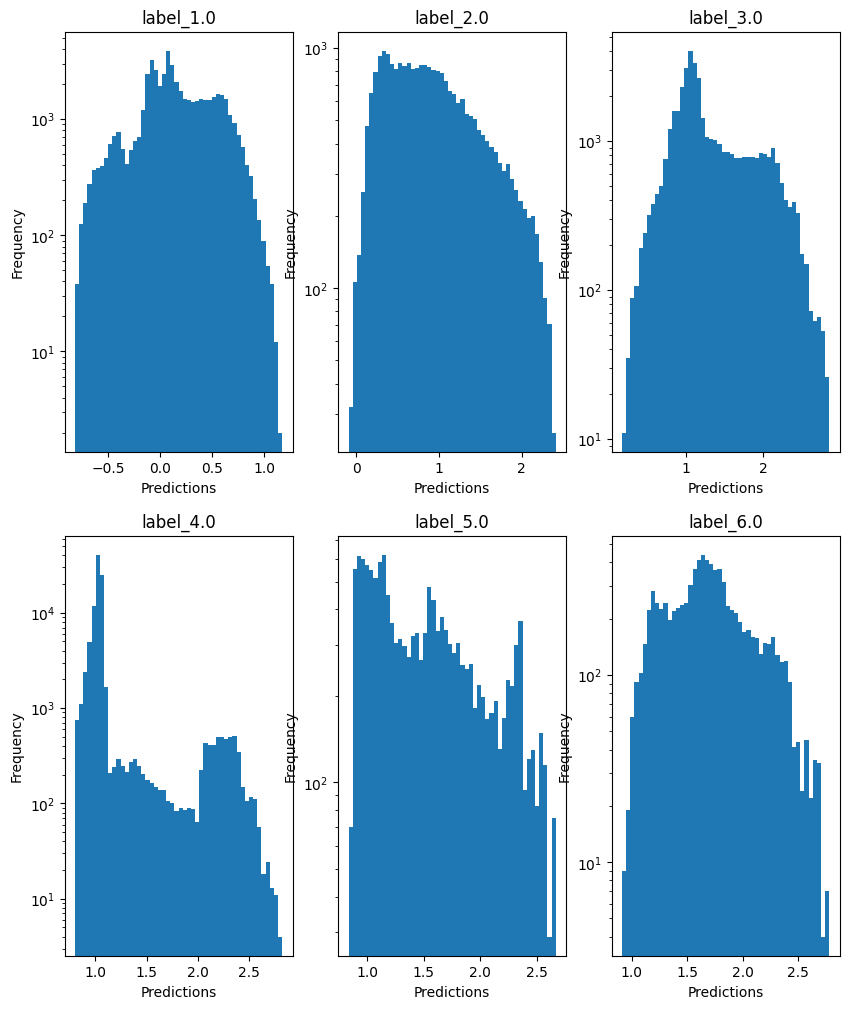

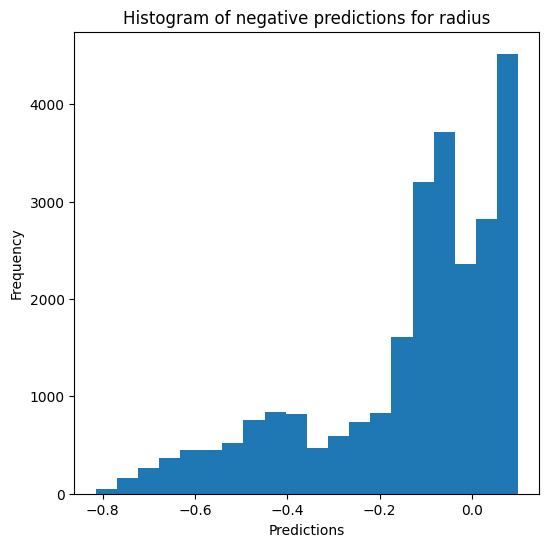

Saving predictions and results...


In [11]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name) #, override=False, use_preds=True

### Decision tree

In [12]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_standard train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9996219085610152
  RMSE :  0.05867615545142638
  MAE :  0.013536659067978513
  MedAE :  0.0
  CORR :  0.9998109427192199
  MAX_ER :  1.3419999999999987
  Percentiles : 
    75th percentile :  0.0010000000000000009
    90th percentile :  0.02100000000000013
    95th percentile :  0.06899999999999995
    99th percentile :  0.29000000000000037

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9999443522365348
  RMSE :  0.025011263930239436
  MAE :  0.006423686453812799
  MedAE :  0.0
  CORR :  0.999972289836999
  MAX_ER :  0.6719999999999988
  Percentiles : 
    75th percentile :  0.0009999999999994458
    90th percentile :  0.017000000000000015
    95th percentile :  0.041999999999999815
    99th percentile :  0.10200000000000031

mass results for the label category with a value of 3.0
  value range :  0.655 - 13.903
  RVE :  0.9999167405979

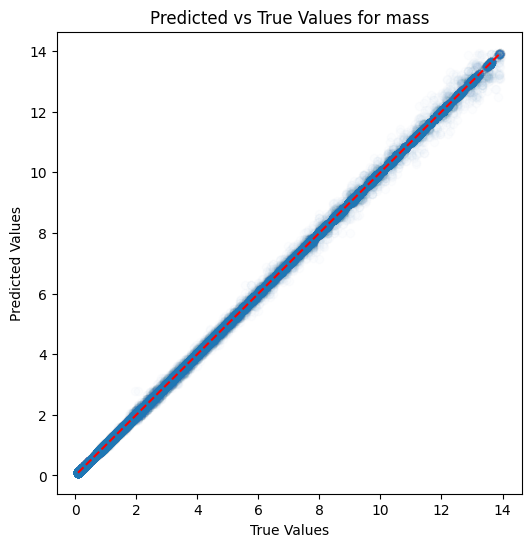

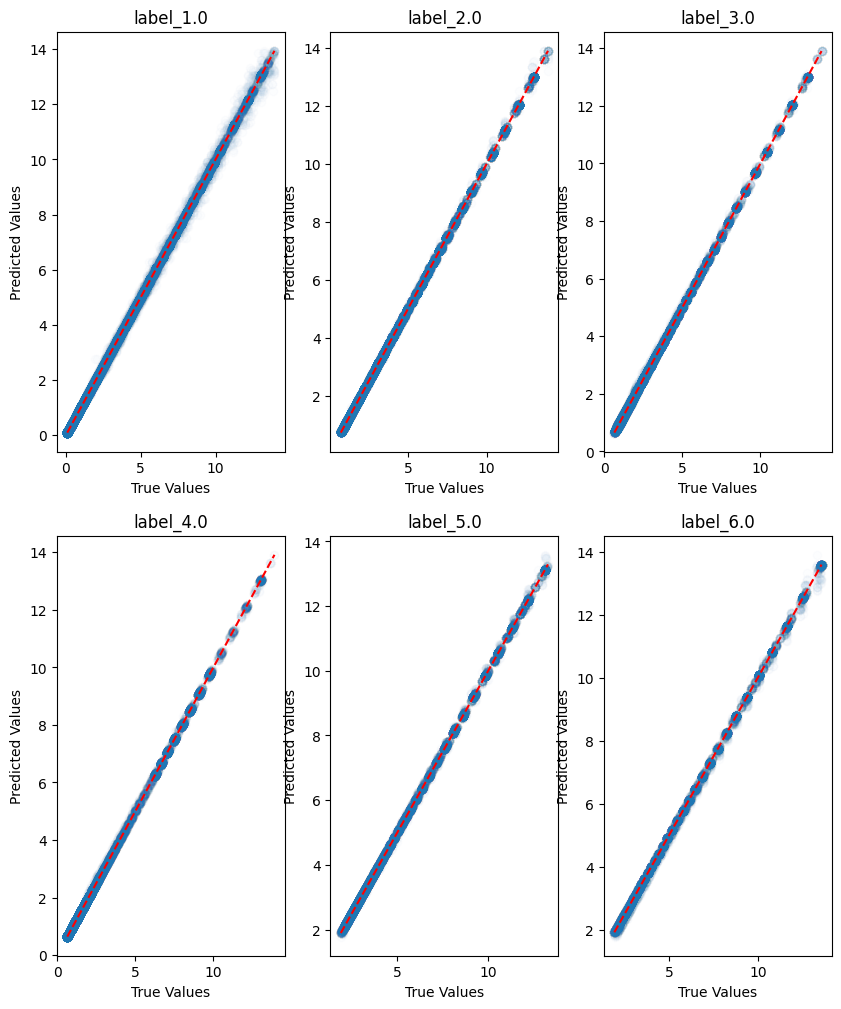

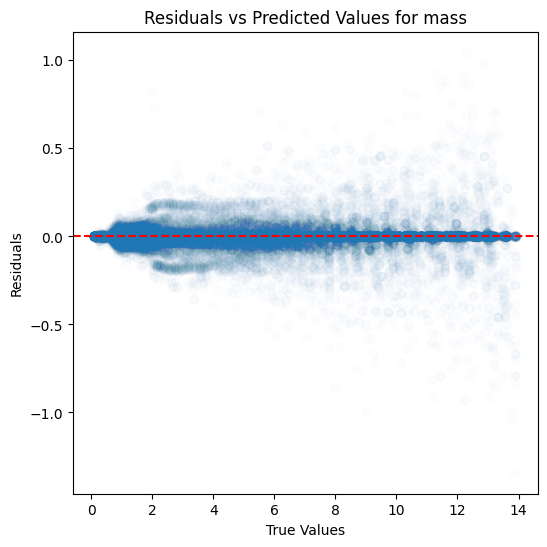

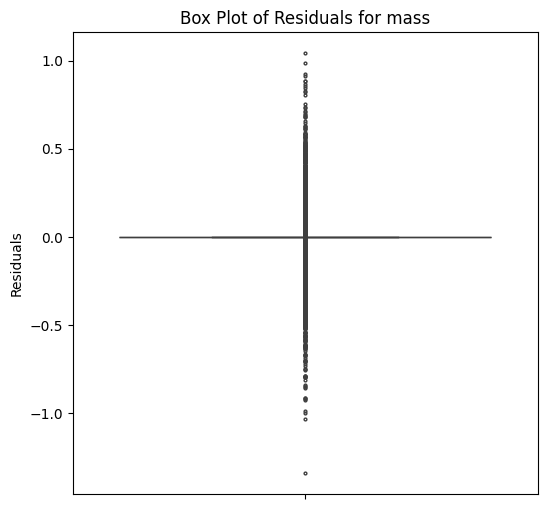

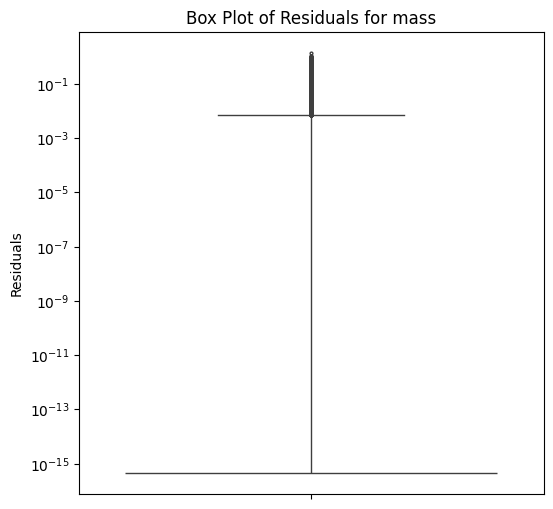

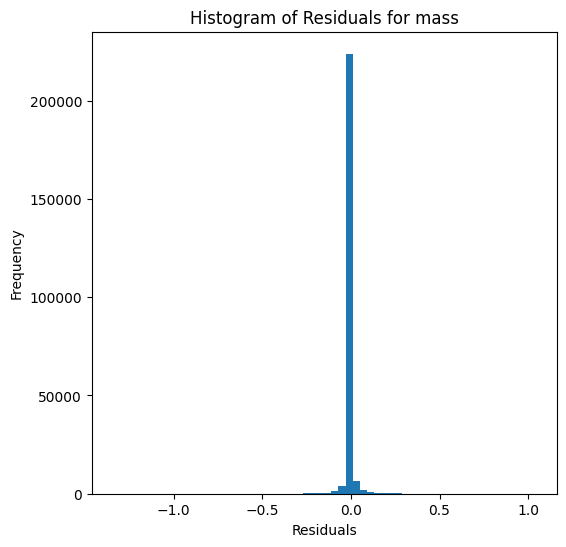

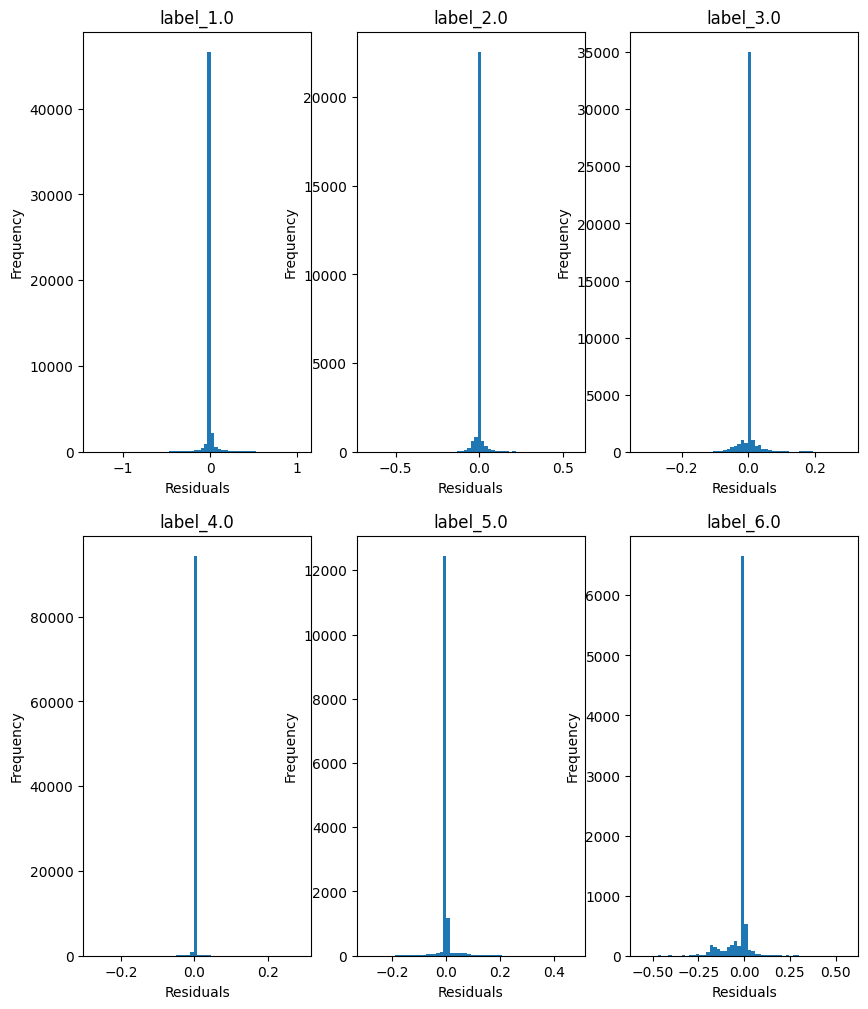

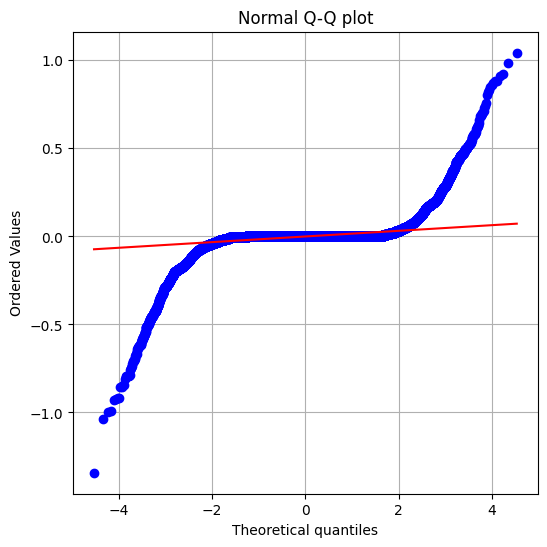

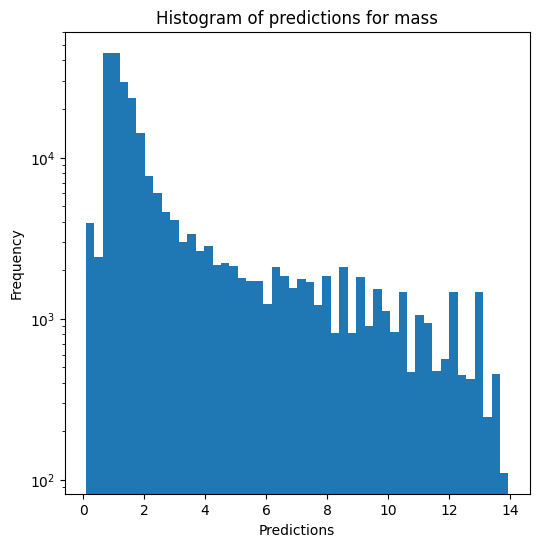

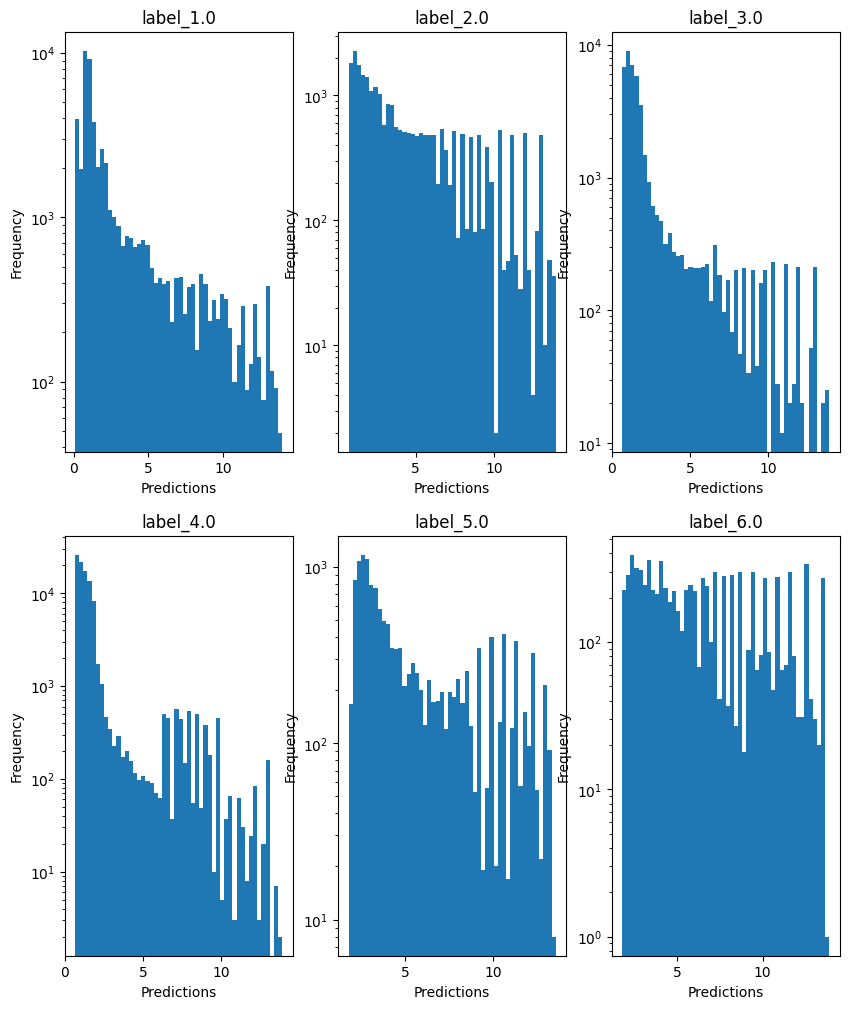

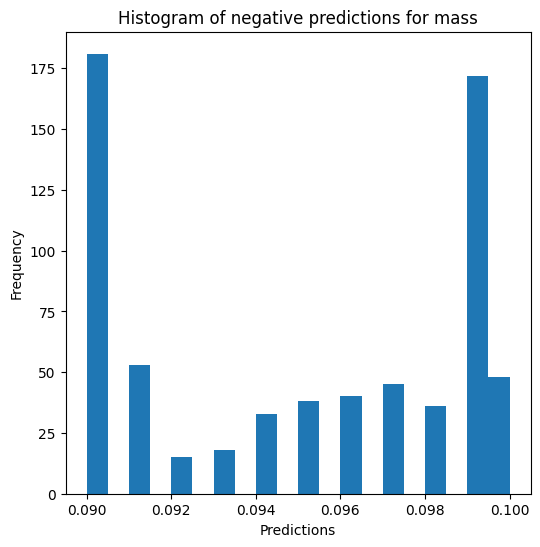

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9996345283950285
  RMSE :  0.006996605638879021
  MAE :  0.002553206260560504
  MedAE :  2.7755575615628914e-17
  CORR :  0.9998173330836768
  MAX_ER :  0.15067566342895866
  Percentiles : 
    75th percentile :  0.001750366396182642
    90th percentile :  0.007671740876614319
    95th percentile :  0.013858184964397377
    99th percentile :  0.03232782628093739

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.999286585512361
  RMSE :  0.014461955905885773
  MAE :  0.005587254635958368
  MedAE :  0.0
  CORR :  0.999647617777793
  MAX_ER :  0.3374512485512551
  Percentiles : 
    75th percentile :  0.006687613799110564
    90th percentile :  0.019420456762000497
    95th percentile :  0.02565292628084658
    99th percentile :  0.04767228484213172

radius results for the label category 

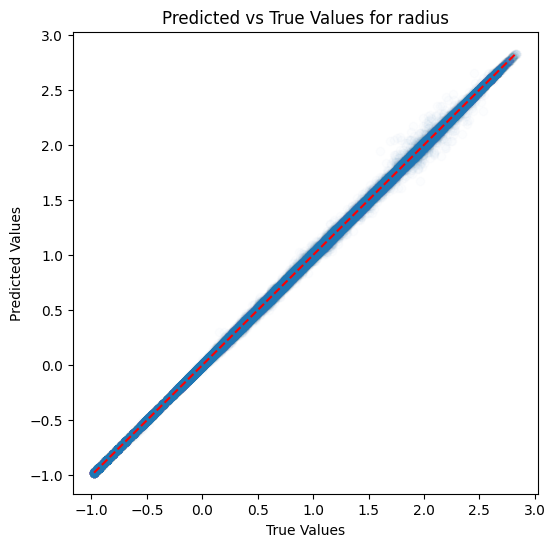

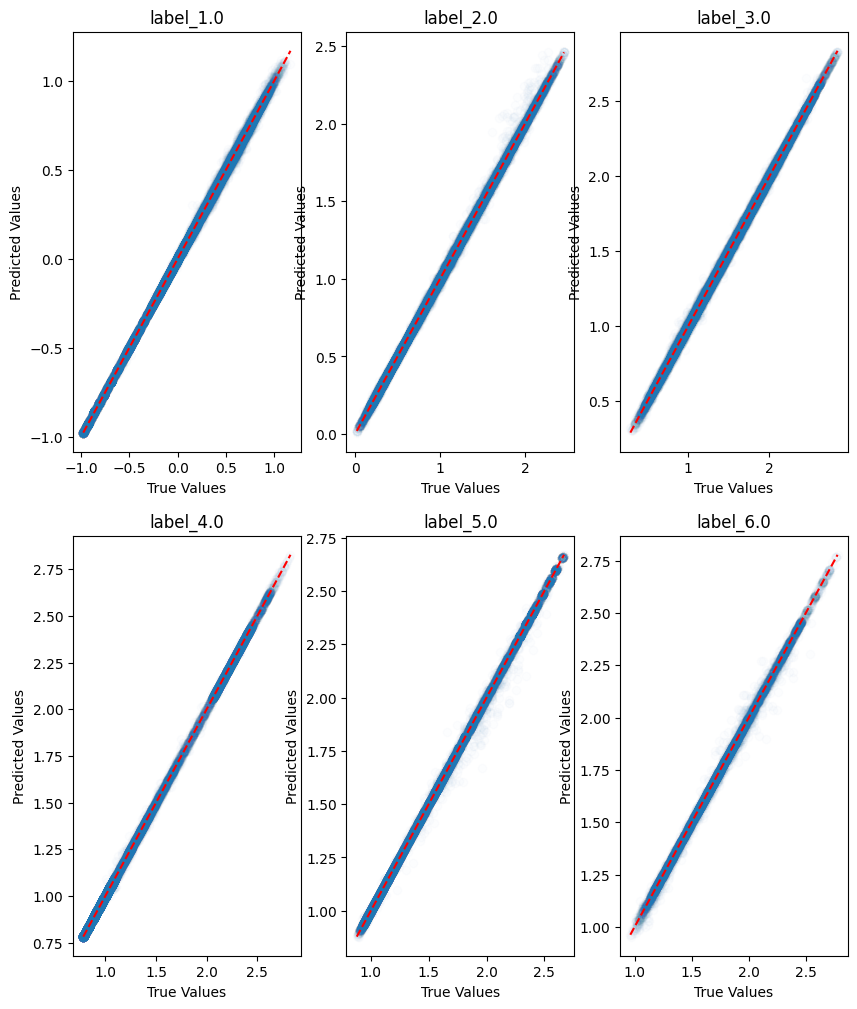

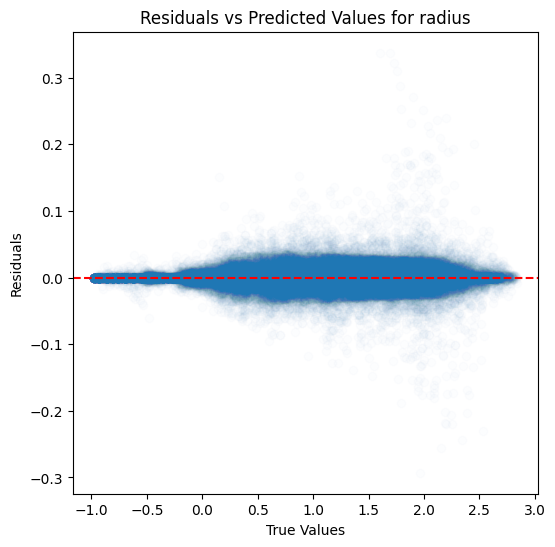

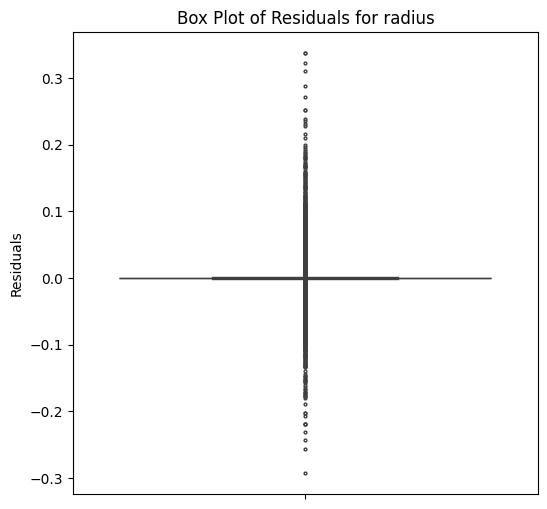

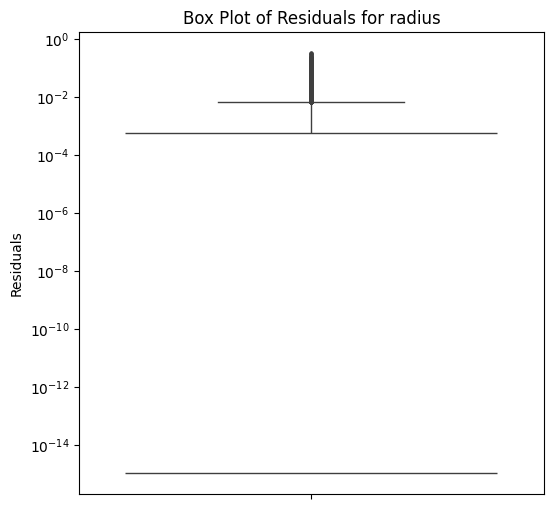

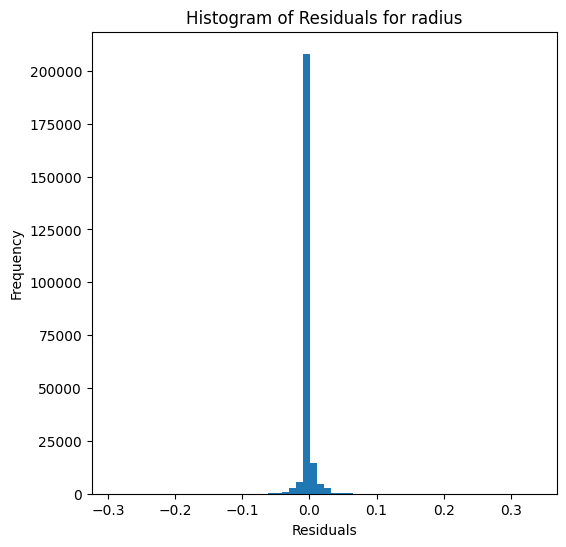

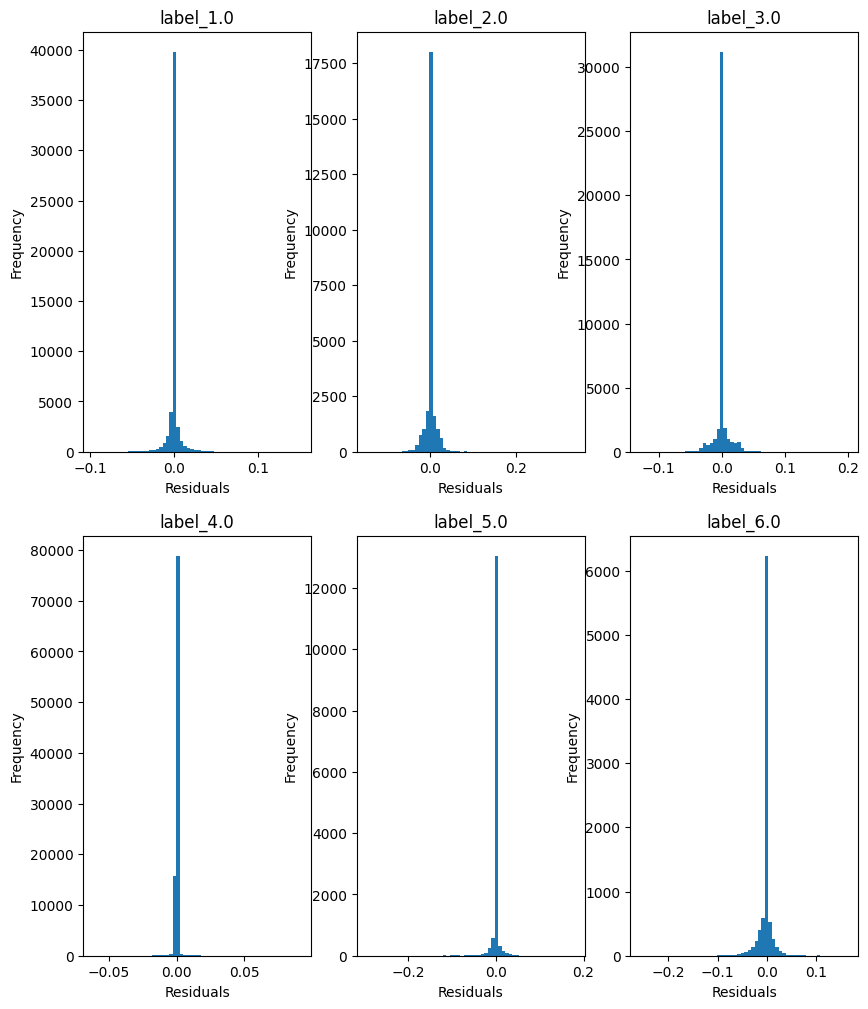

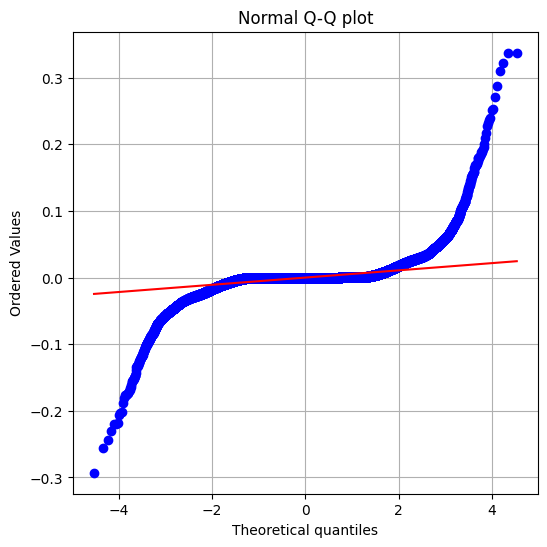

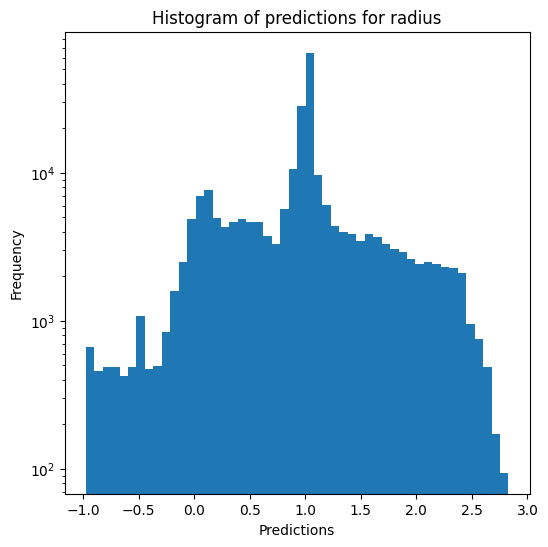

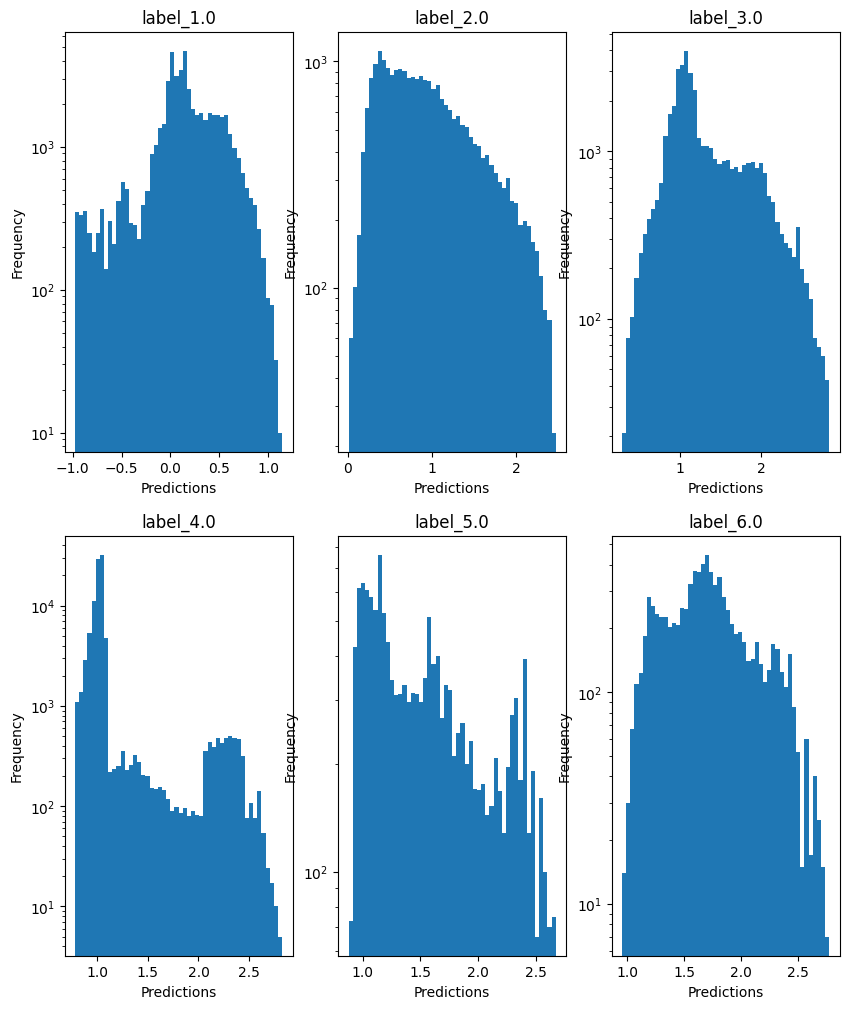

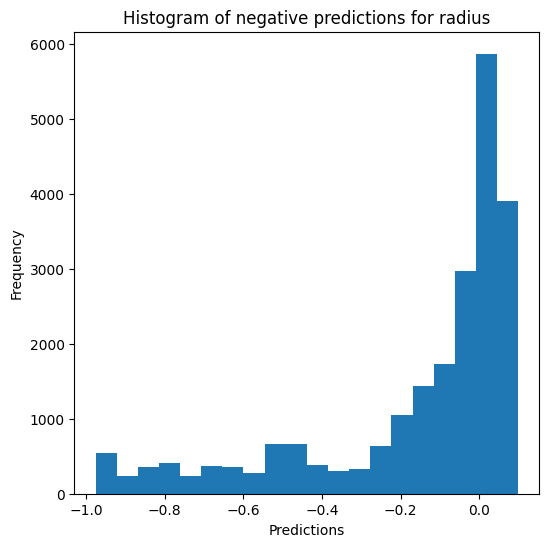

Saving predictions and results...


In [13]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### K-nearest neighbours

In [14]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_standard train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9991870656117123
  RMSE :  0.08603870745943935
  MAE :  0.034480009854830775
  MedAE :  0.007999999999999785
  CORR :  0.9995964587141344
  MAX_ER :  1.5036000000000023
  Percentiles : 
    75th percentile :  0.029999999999999805
    90th percentile :  0.09200000000000053
    95th percentile :  0.1656000000000004
    99th percentile :  0.38040000000000046

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9981182560259284
  RMSE :  0.14675699227979913
  MAE :  0.069231664600124
  MedAE :  0.02440000000000042
  CORR :  0.9991428840400433
  MAX_ER :  1.6719999999999988
  Percentiles : 
    75th percentile :  0.07179999999999964
    90th percentile :  0.172
    95th percentile :  0.284529999999999
    99th percentile :  0.6963860000000005

mass results for the label category with a value of 3.0
  value range :  0.655 - 13.903
  RVE :  0.999542

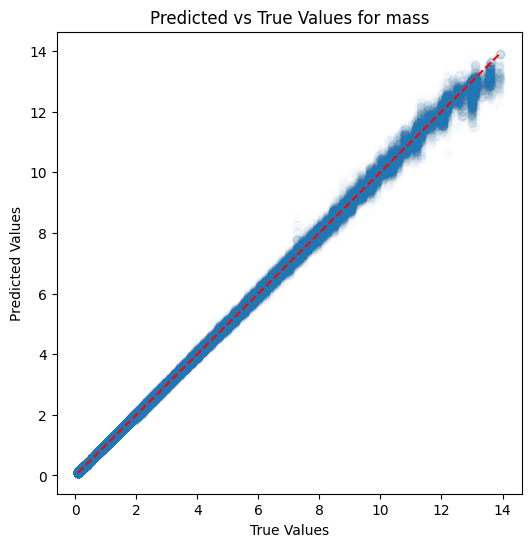

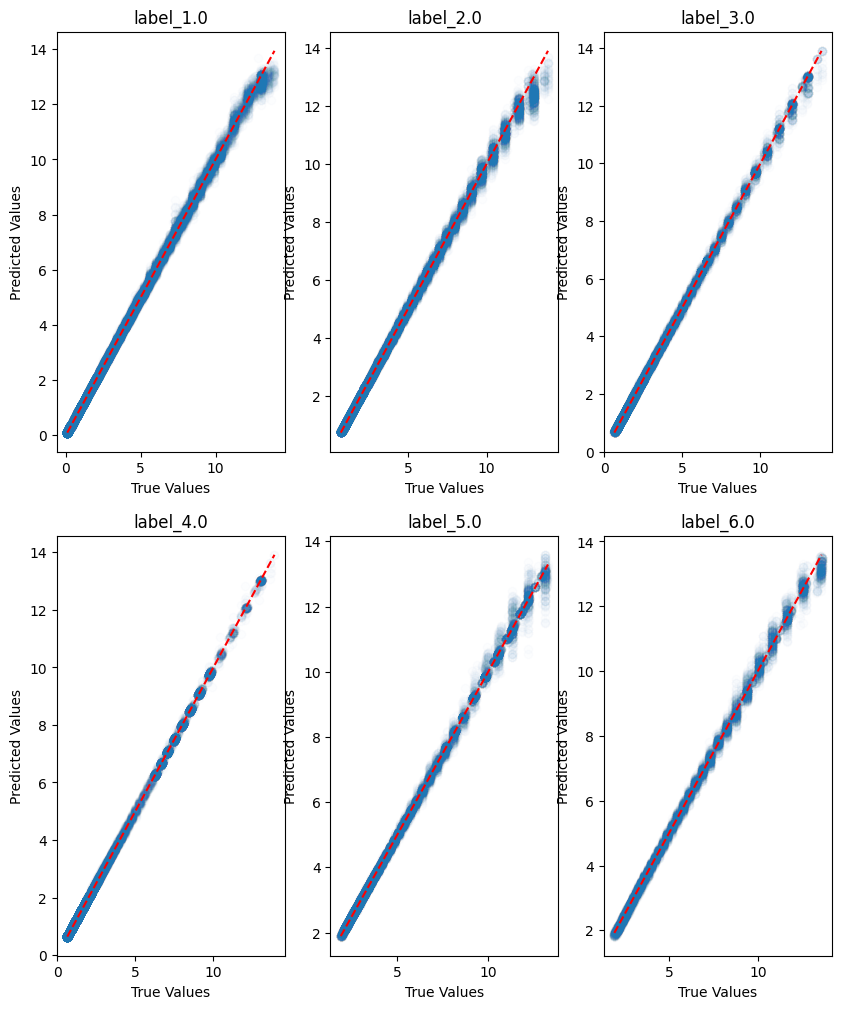

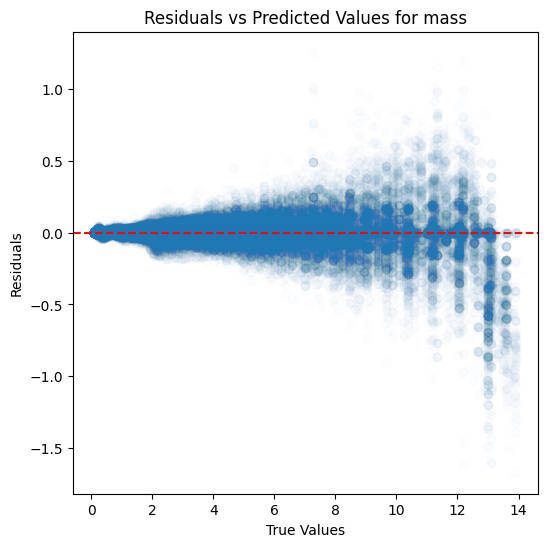

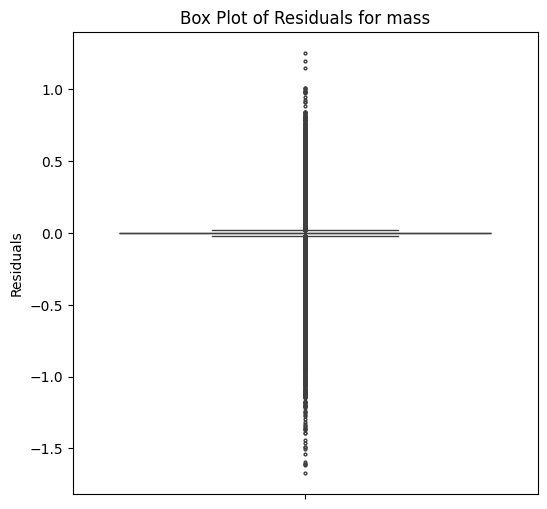

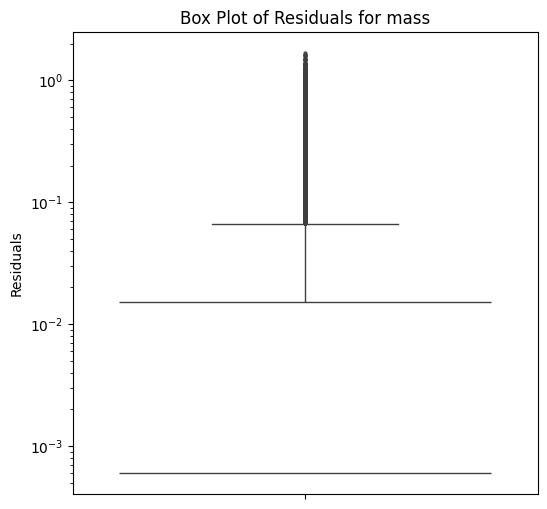

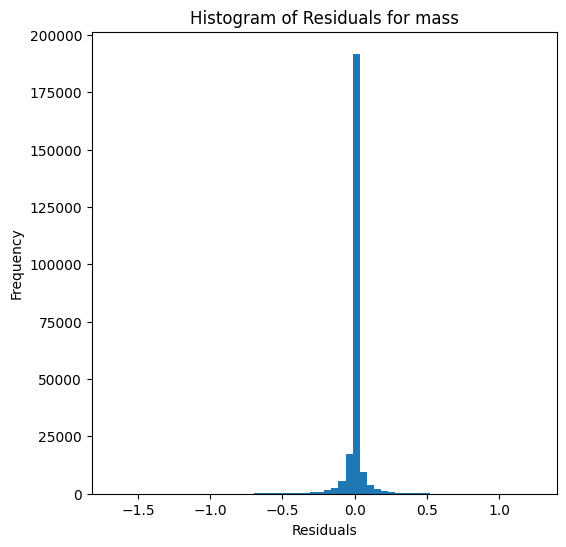

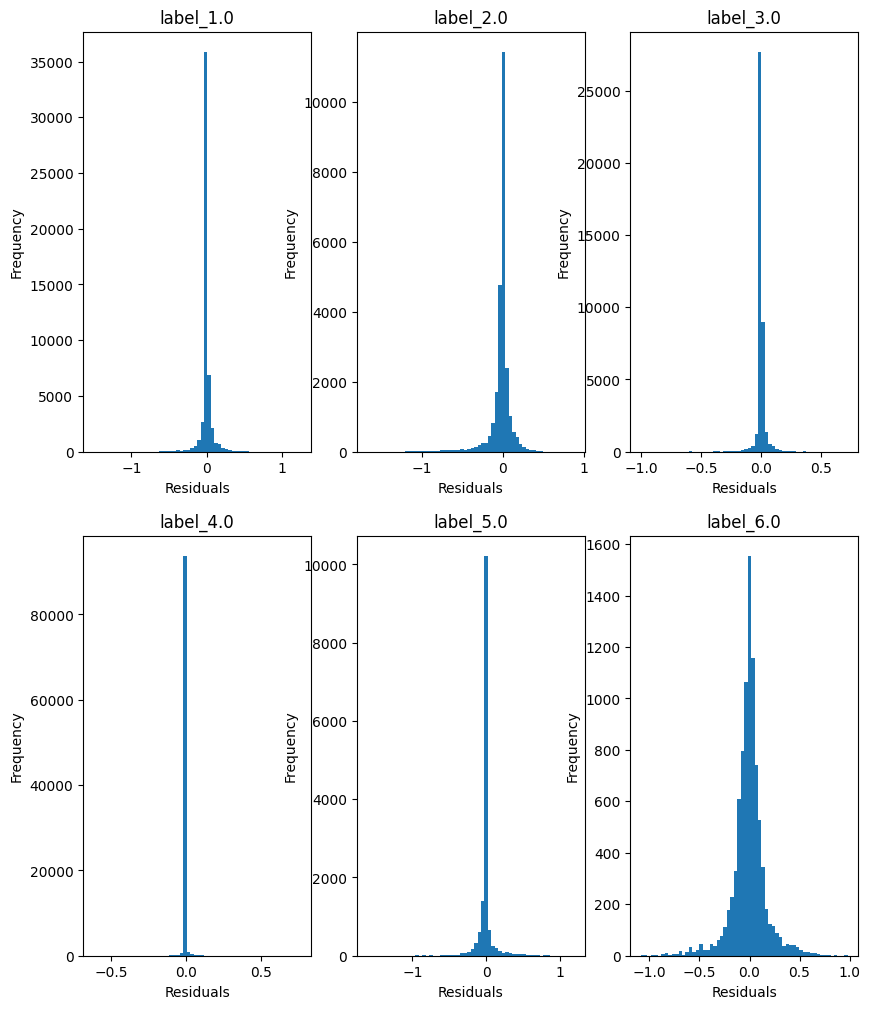

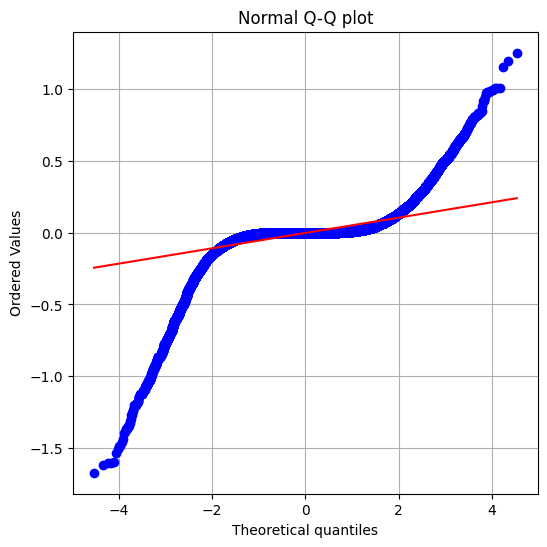

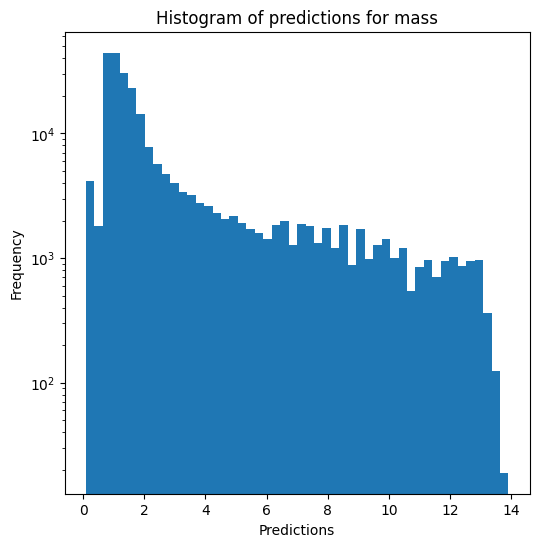

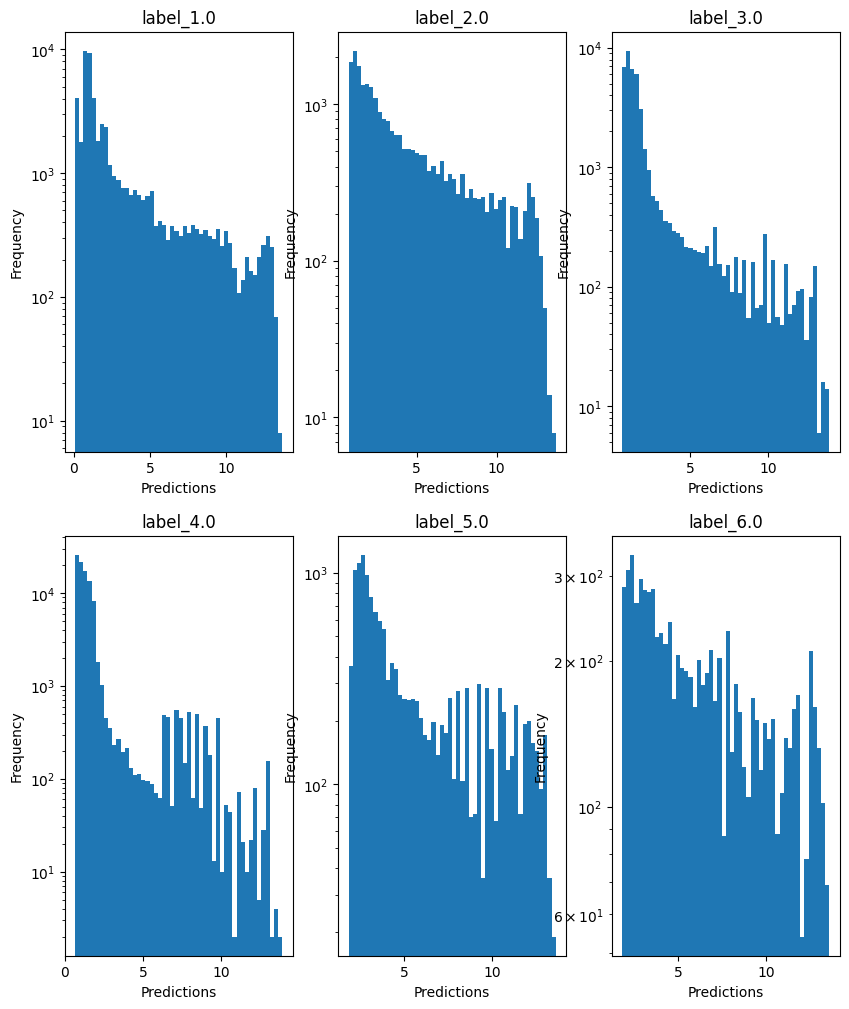

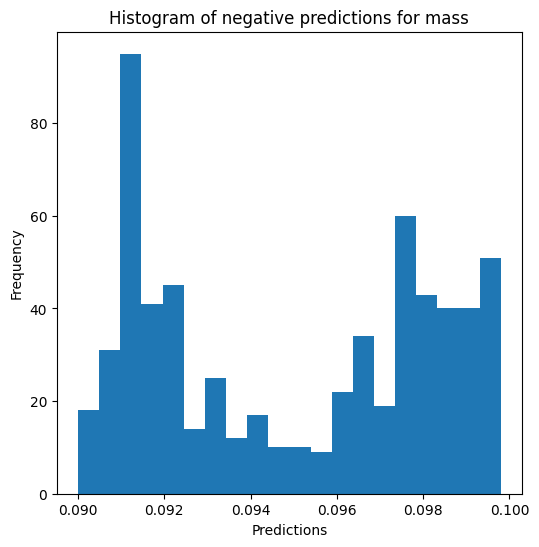


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9994756852347223
  RMSE :  0.0084000173743657
  MAE :  0.005453142569442962
  MedAE :  0.003240593190573876
  CORR :  0.9997382842320102
  MAX_ER :  0.0721214407748455
  Percentiles : 
    75th percentile :  0.007832356016073086
    90th percentile :  0.013789347288088102
    95th percentile :  0.018084264985677806
    99th percentile :  0.028713715508844936

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9994601413555995
  RMSE :  0.01257165278271453
  MAE :  0.008687331334841536
  MedAE :  0.006431802143535698
  CORR :  0.9997356808912691
  MAX_ER :  0.20228537867526297
  Percentiles : 
    75th percentile :  0.011231412620729575
    90th percentile :  0.018019901749155465
    95th percentile :  0.023466257283036585
    99th percentile :  0.04129933827394055

radius results for the

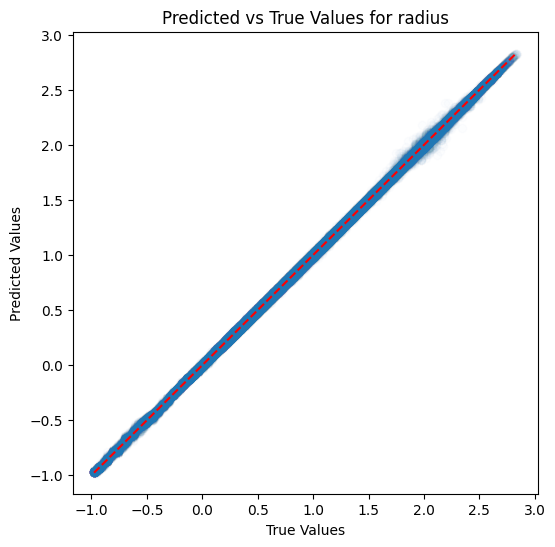

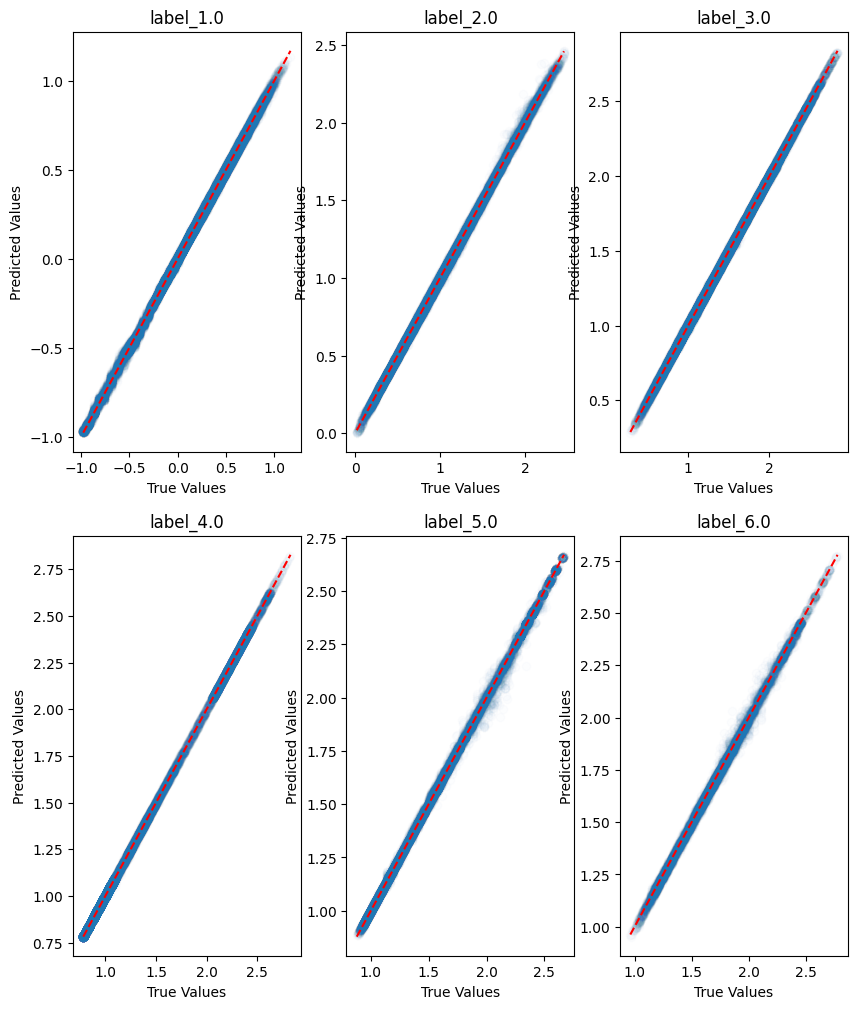

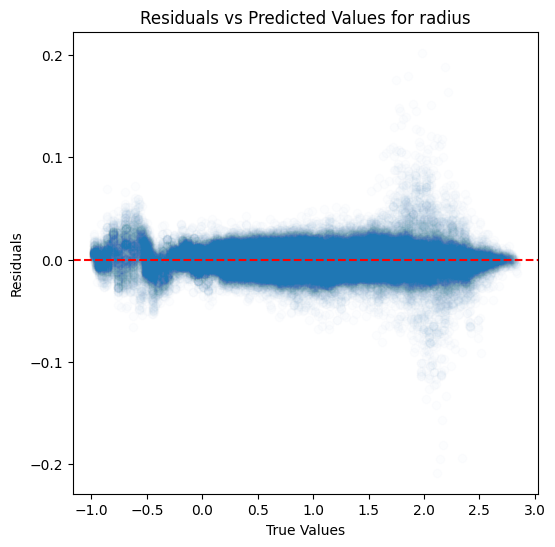

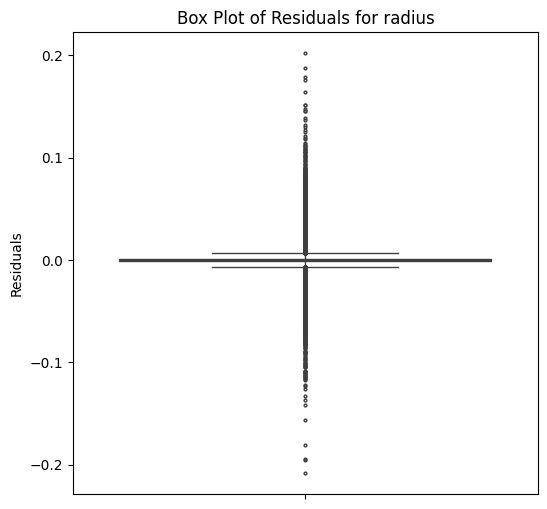

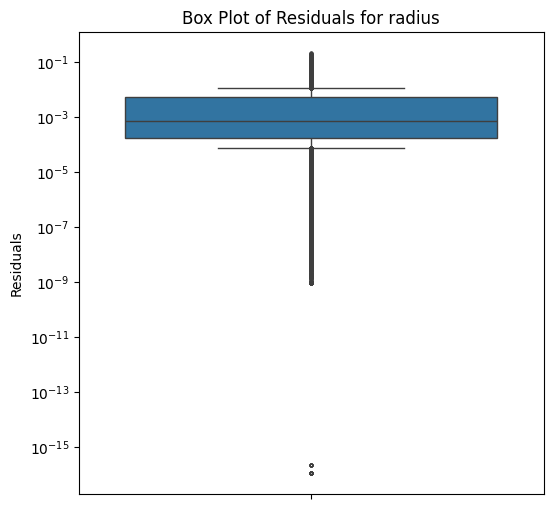

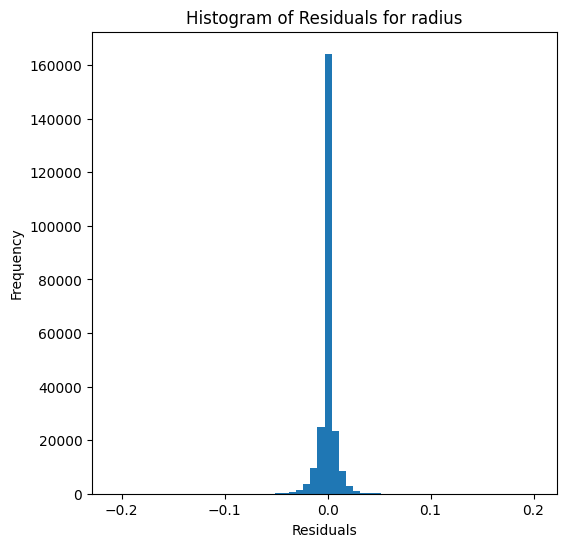

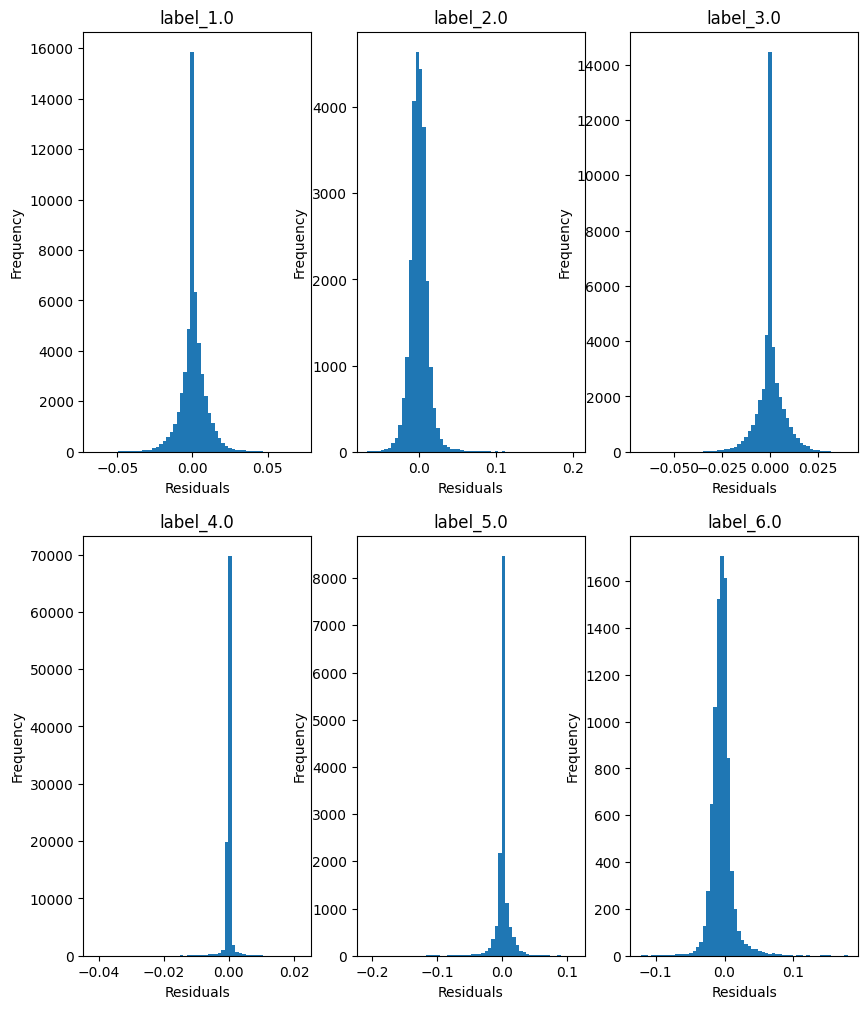

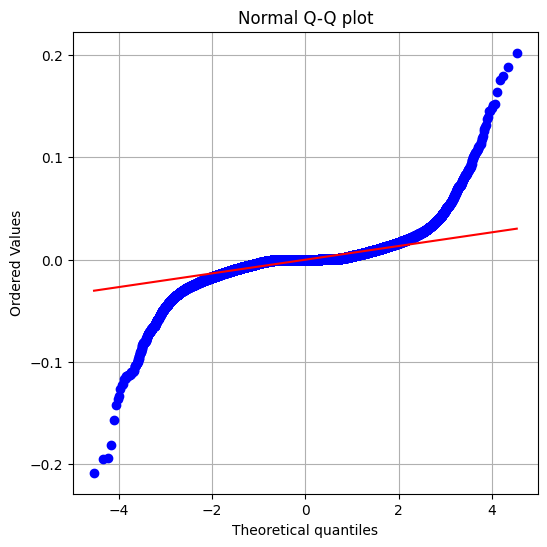

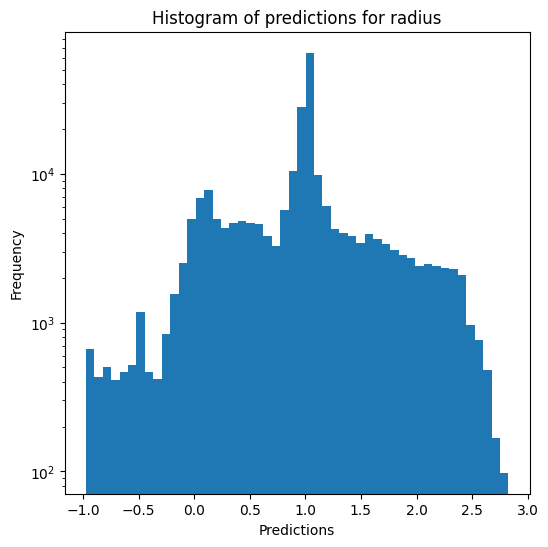

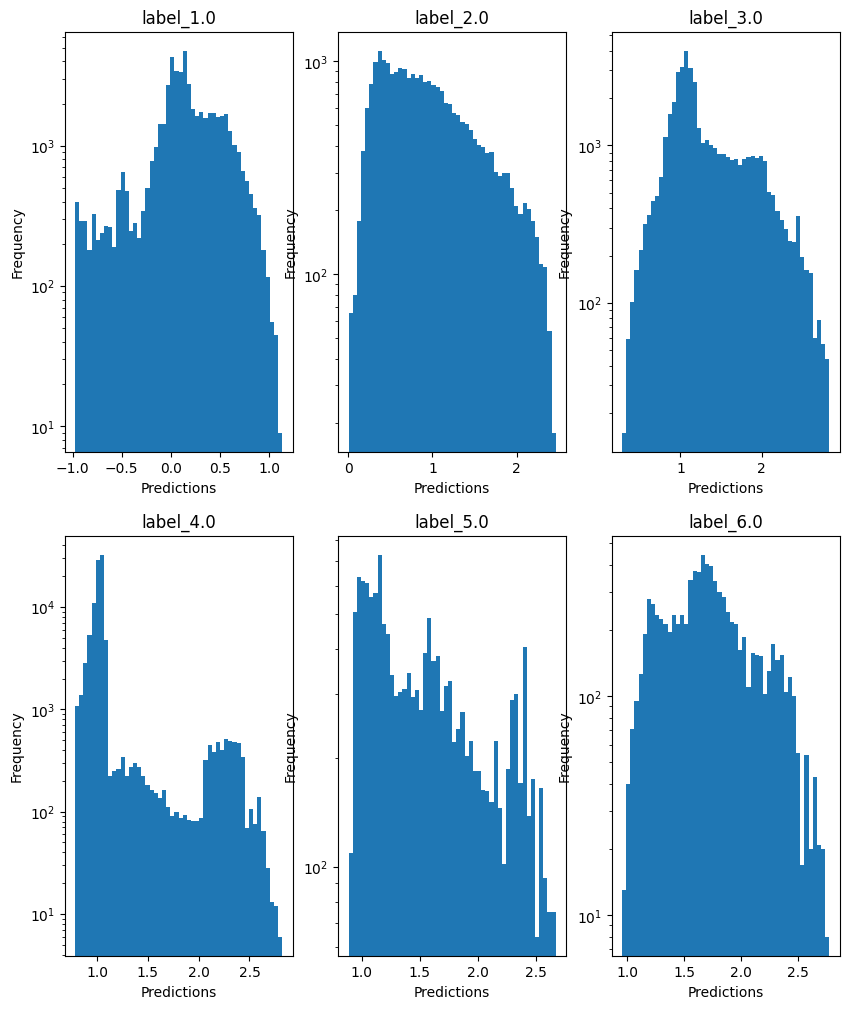

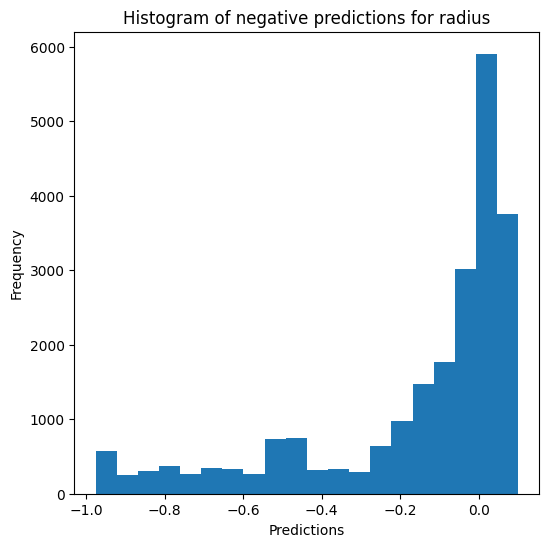

Saving predictions and results...


In [15]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### Random forests

In [16]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_standard train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9998831201396713
  RMSE :  0.03262364149436043
  MAE :  0.008677193692547925
  MedAE :  0.0002700000000015468
  CORR :  0.9999415679567918
  MAX_ER :  0.7756199999999858
  Percentiles : 
    75th percentile :  0.003440000000000498
    90th percentile :  0.019090000000000162
    95th percentile :  0.04383000000000503
    99th percentile :  0.15119899999999922

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9999728936253497
  RMSE :  0.01746186739359308
  MAE :  0.006905188307244531
  MedAE :  0.0006400000000015282
  CORR :  0.9999865090566386
  MAX_ER :  0.5005199999999963
  Percentiles : 
    75th percentile :  0.006992500000011059
    90th percentile :  0.021080000000002742
    95th percentile :  0.033519999999997996
    99th percenti

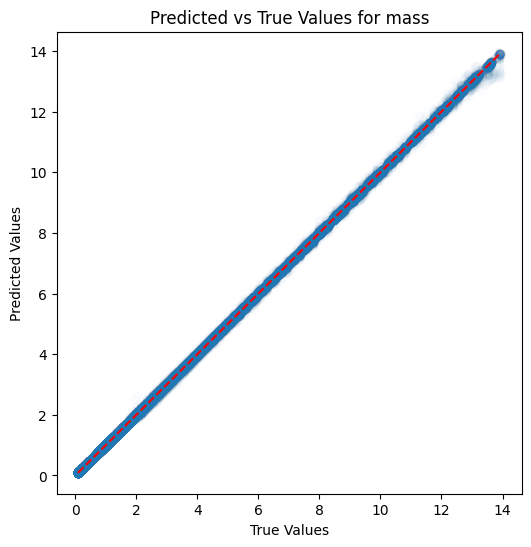

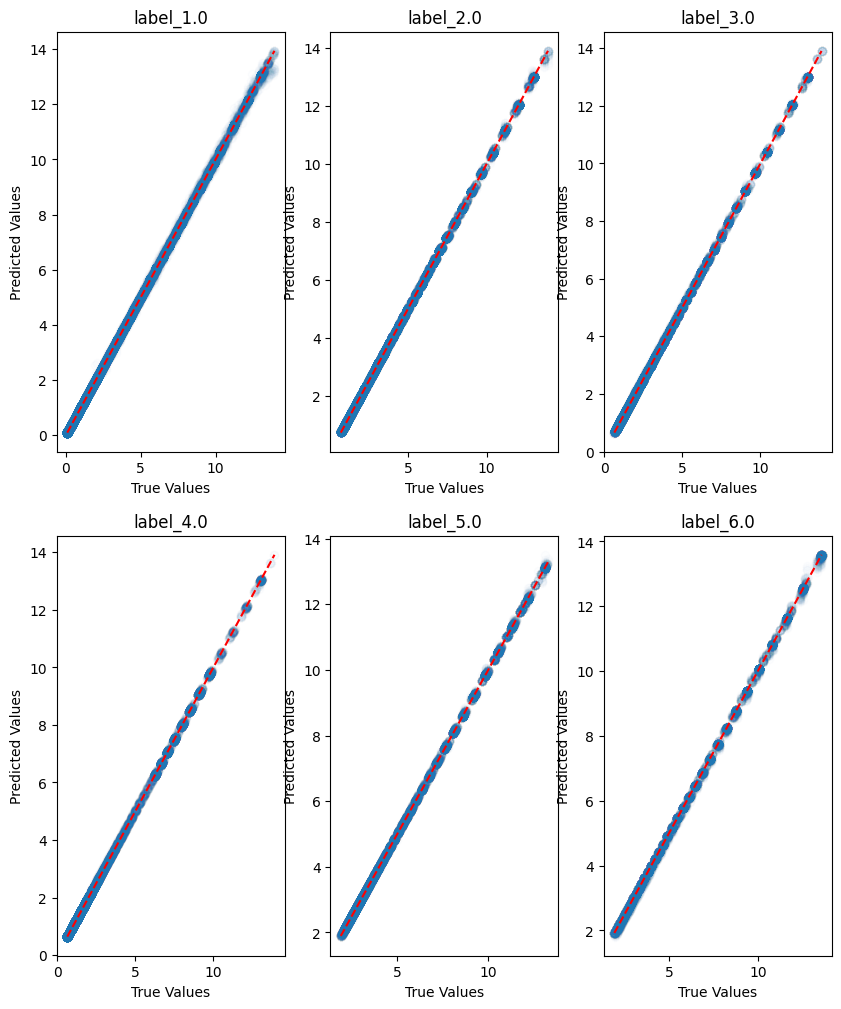

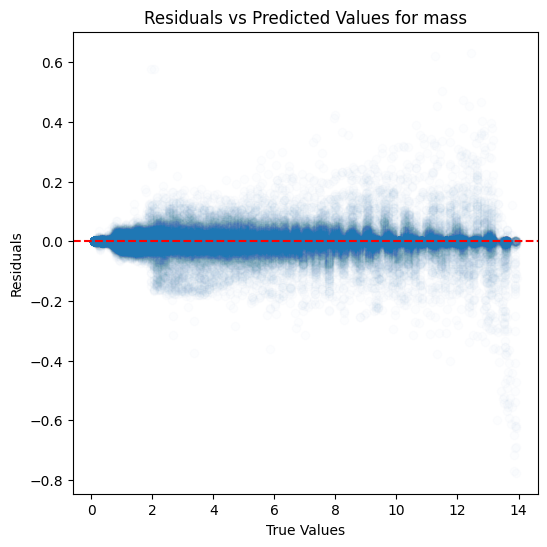

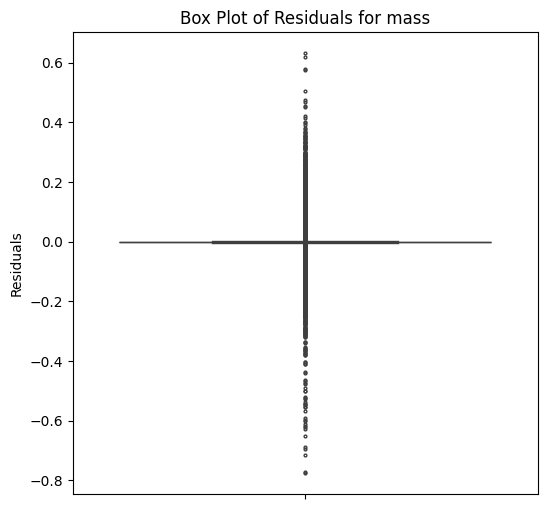

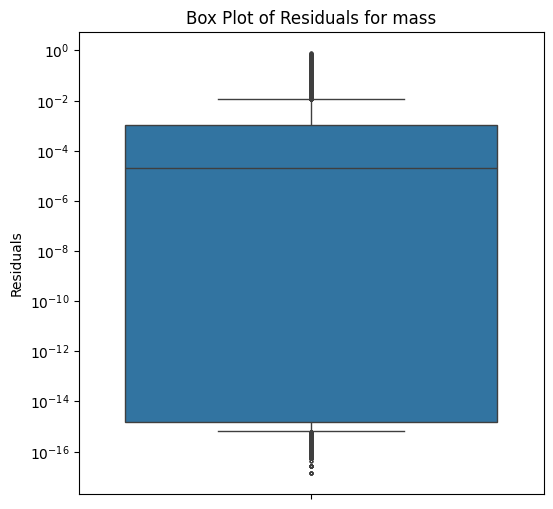

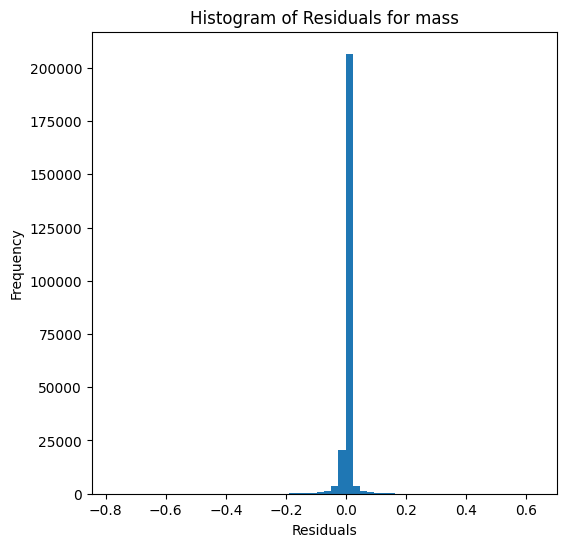

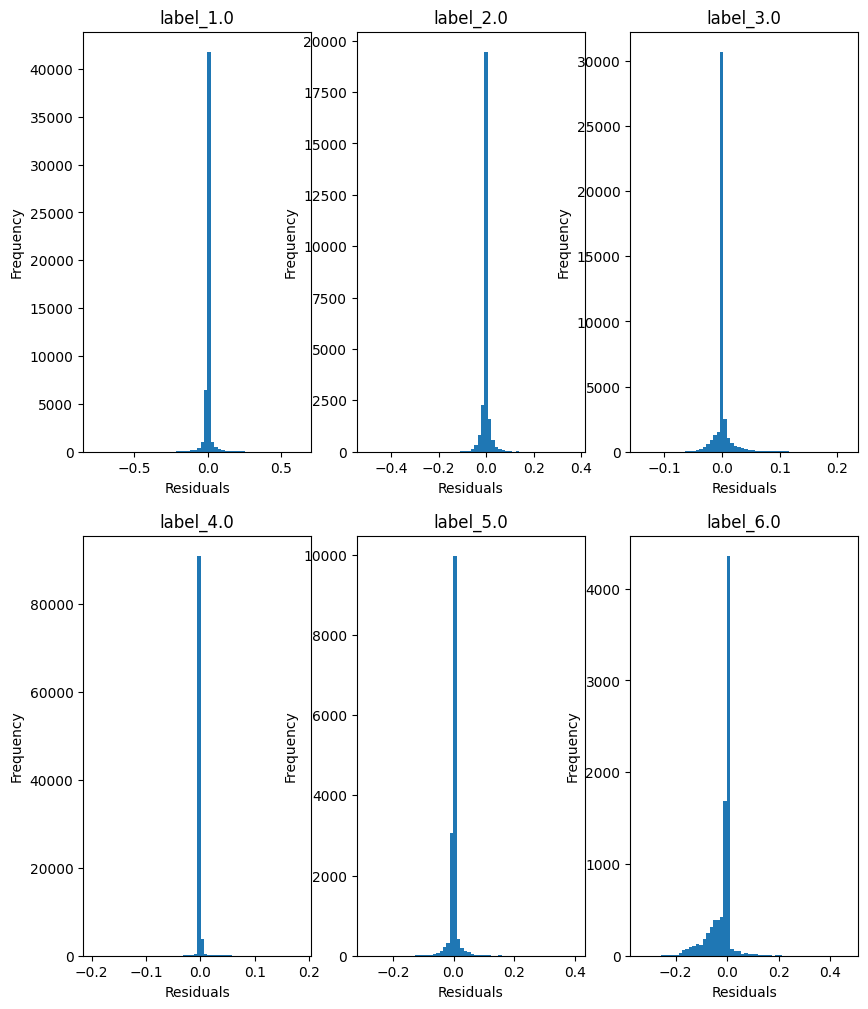

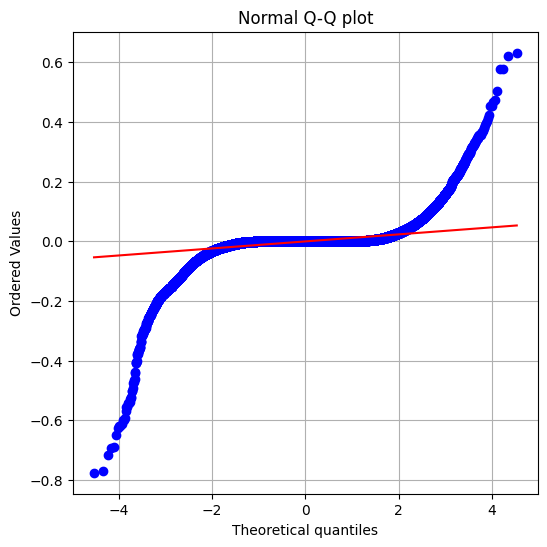

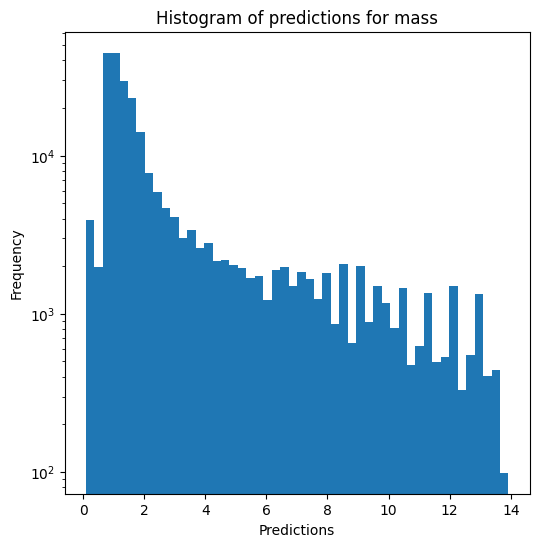

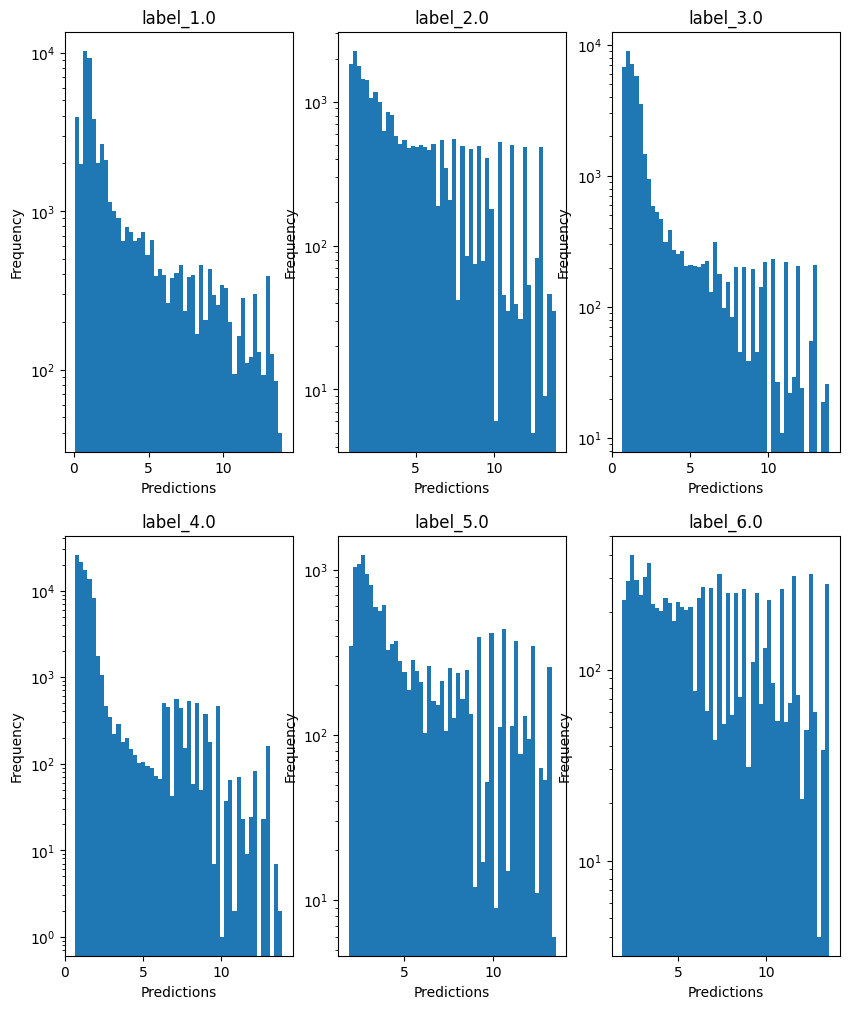

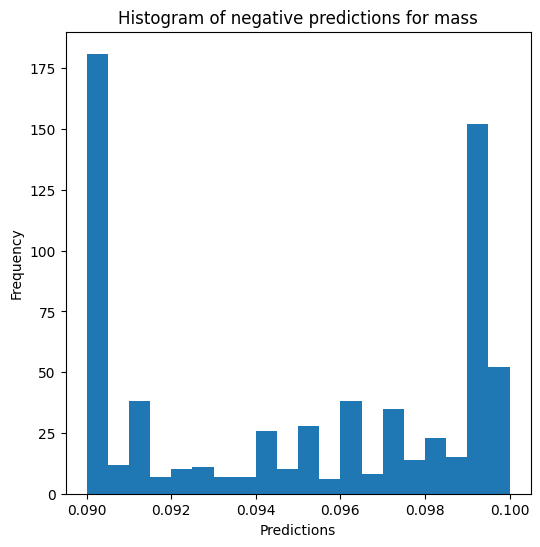


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9999189515266705
  RMSE :  0.0032947943287789994
  MAE :  0.0013186208895189112
  MedAE :  0.00018301904420164883
  CORR :  0.9999595586877013
  MAX_ER :  0.07313813579606146
  Percentiles : 
    75th percentile :  0.0011005853213083006
    90th percentile :  0.003945601670025389
    95th percentile :  0.006769564647115978
    99th percentile :  0.014448240701283093

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9997684371333498
  RMSE :  0.008263832364295466
  MAE :  0.0028267726089239477
  MedAE :  0.00045774355747563167
  CORR :  0.9998885331901988
  MAX_ER :  0.2828723233822239
  Percentiles : 
    75th percentile :  0.002723920539949576
    90th percentile :  0.007787400161131307
    95th percentile :  0.012024693484038404
    99th percentile :  0.028426396344623364

radius res

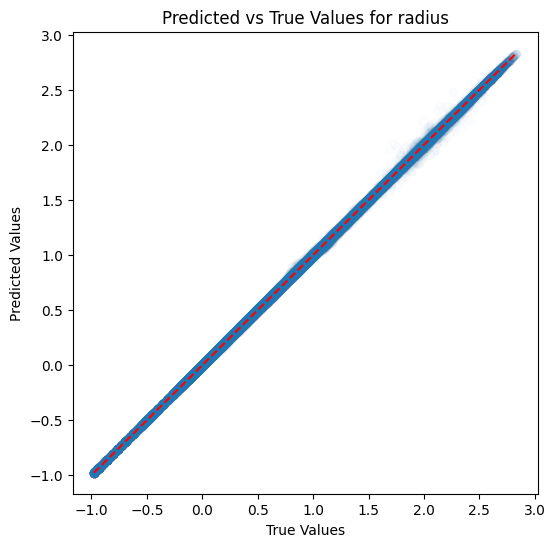

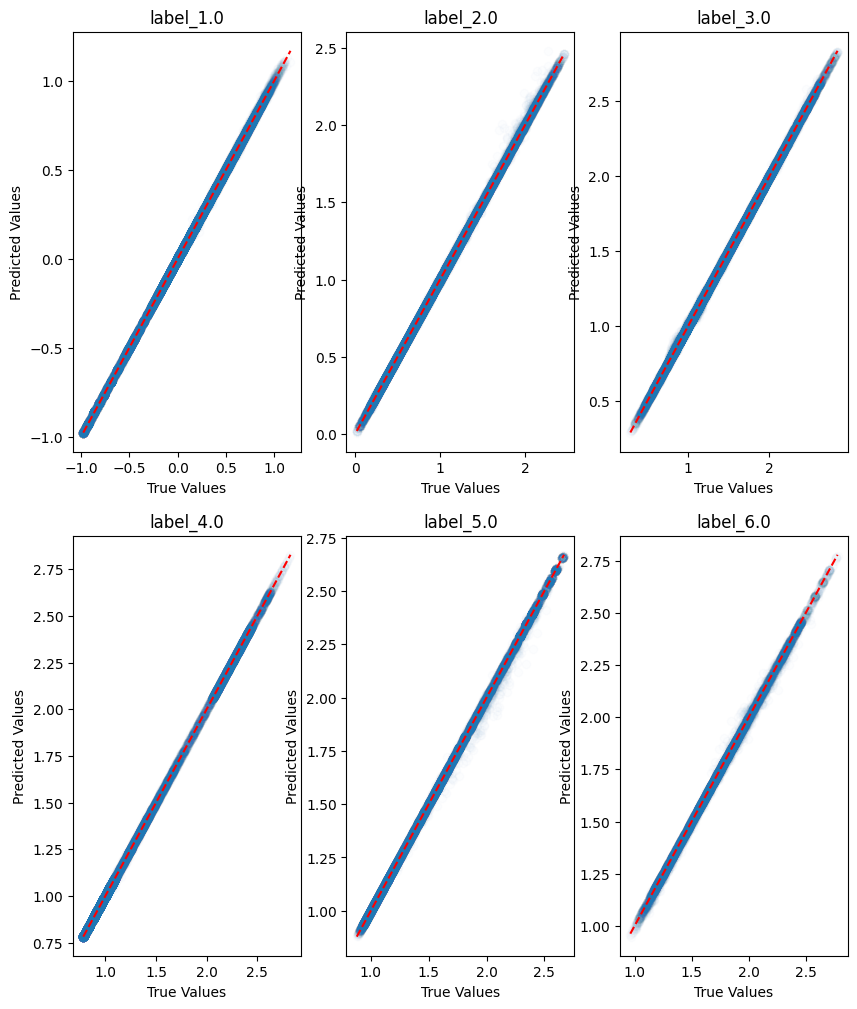

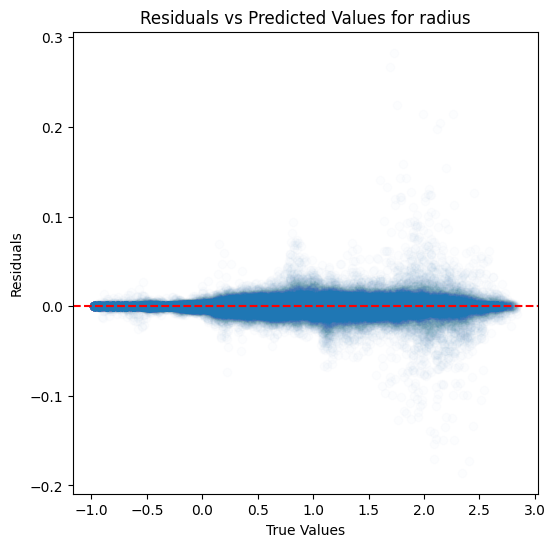

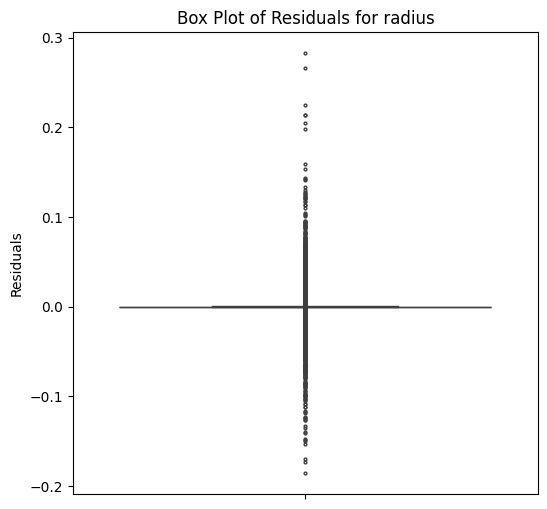

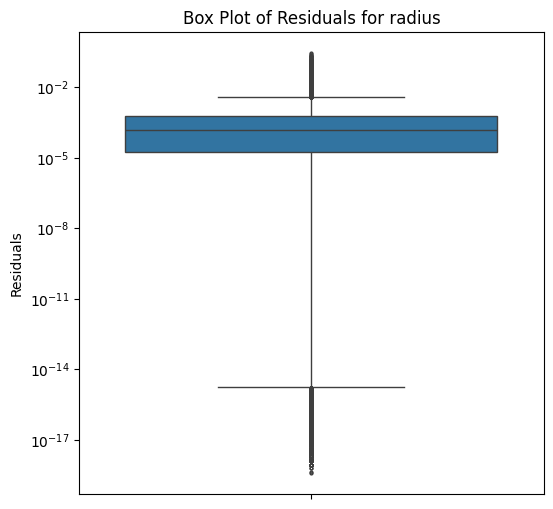

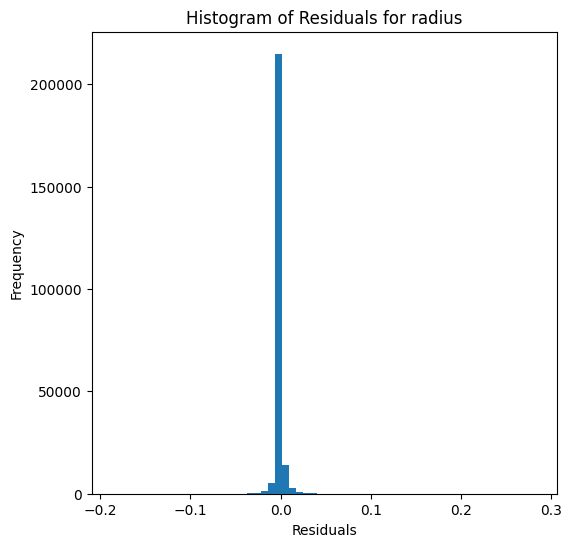

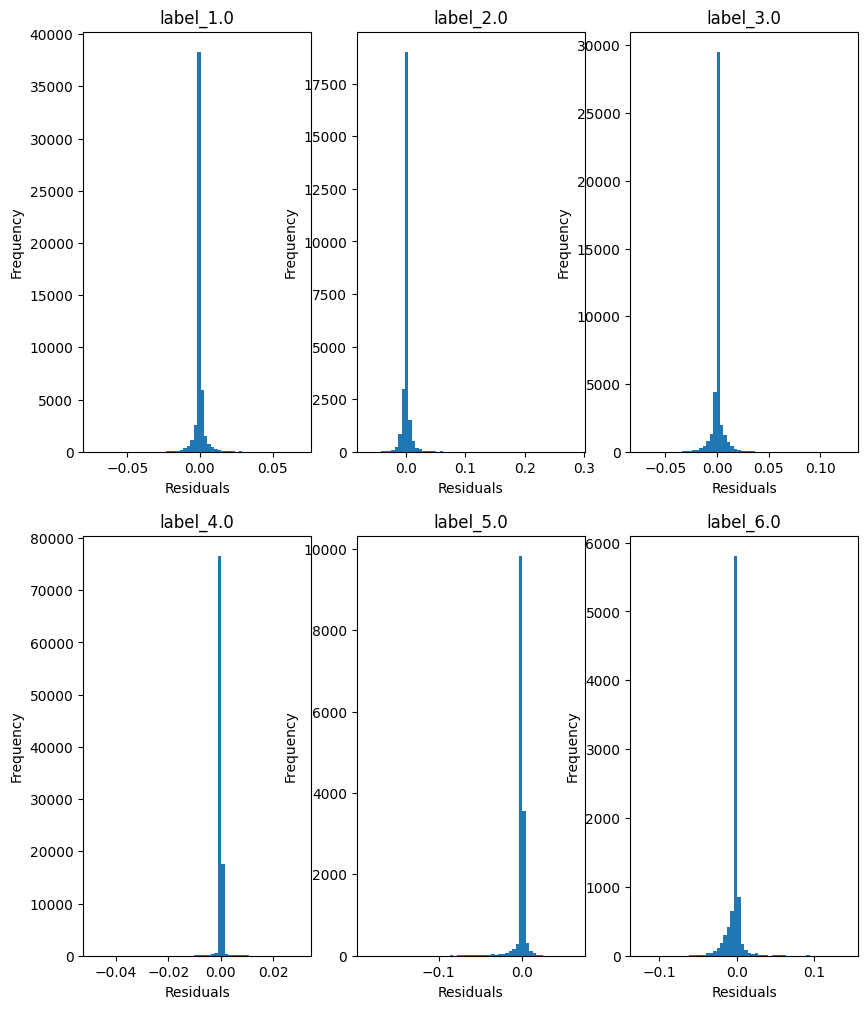

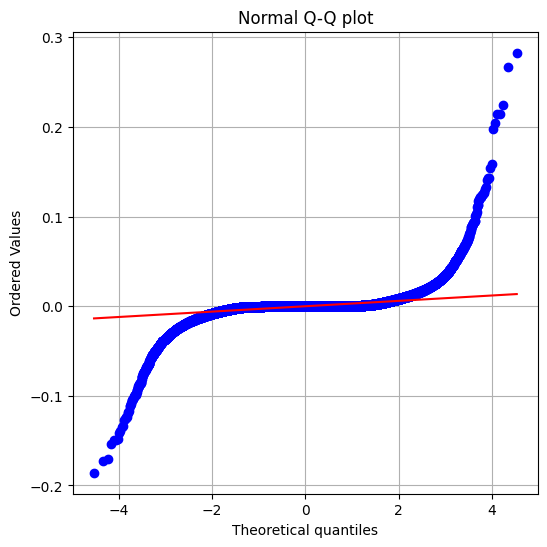

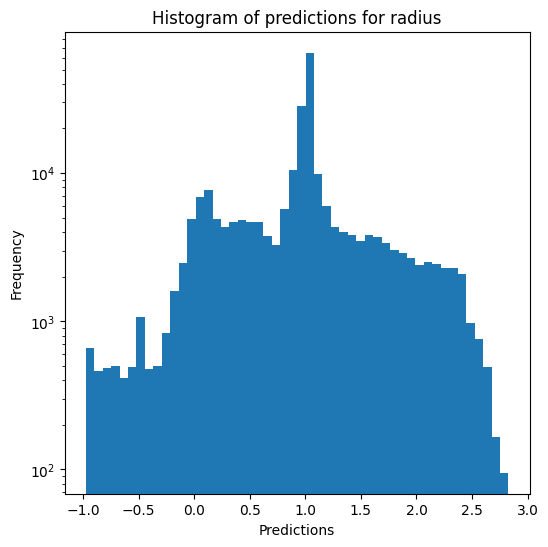

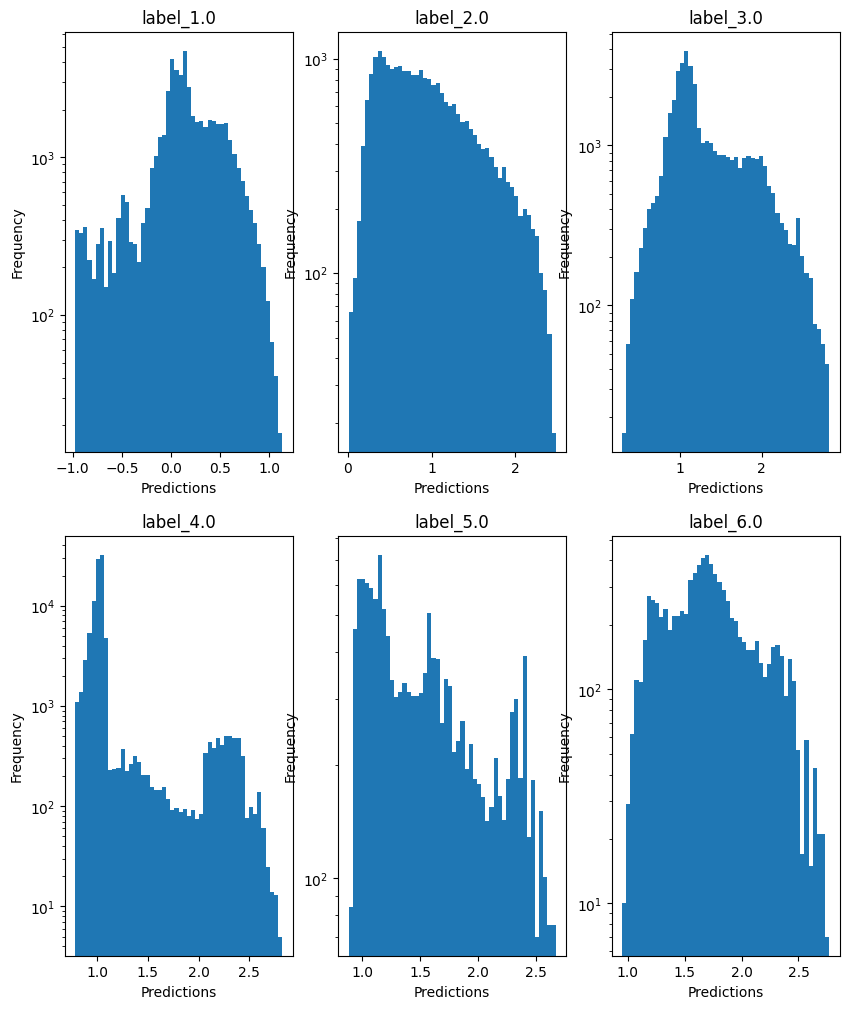

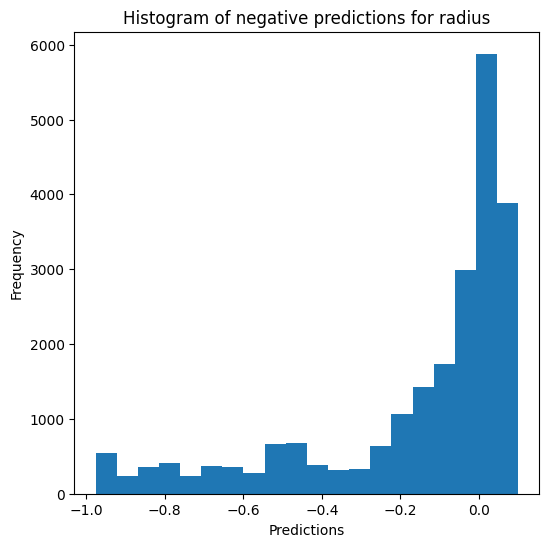

Saving predictions and results...


In [17]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)
# average depth de 44-46

### XGBoost

In [18]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_standard train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9991350851722829
  RMSE :  0.0887554156625211
  MAE :  0.046886387633201056
  MedAE :  0.020626248836517425
  CORR :  0.999567813034968
  MAX_ER :  1.4695928878784184
  Percentiles : 
    75th percentile :  0.05201218032836952
    90th percentile :  0.11996983242034909
    95th percentile :  0.18982356643676757
    99th percentile :  0.37039495620727525

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.999888070822217
  RMSE :  0.03612342170599431
  MAE :  0.02399718580019451
  MedAE :  0.01514275693893452
  CORR :  0.9999466740441237
  MAX_ER :  0.3200783462524406
  Percentiles : 
    75th percentile :  0.031249127388000564
    90th percentile :  0.05624012413024876
    95th percentile :  0.07732287445068352
    99th percentile :  0.129

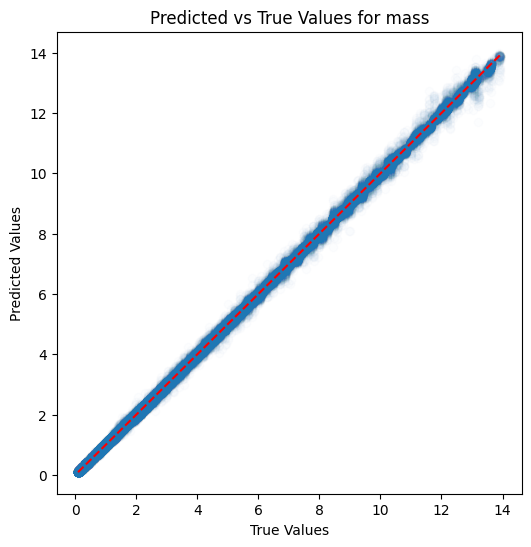

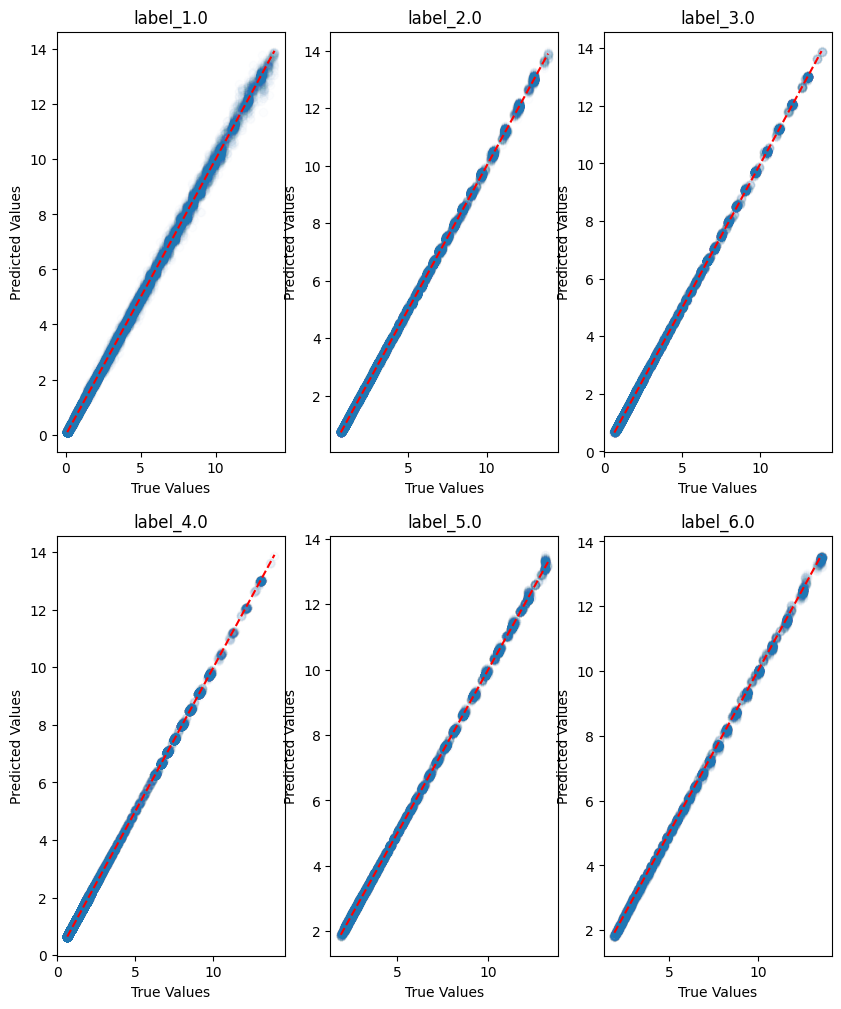

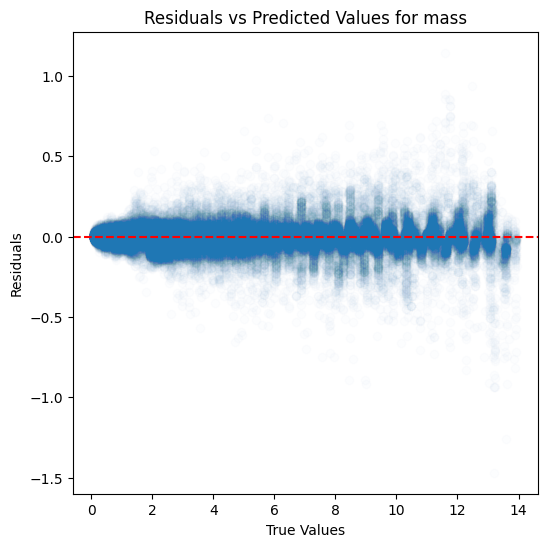

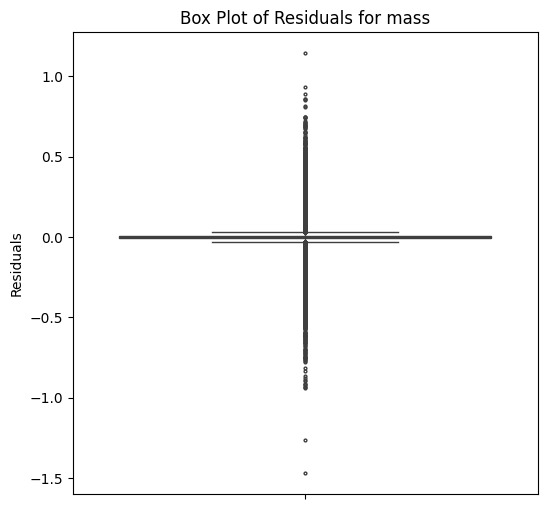

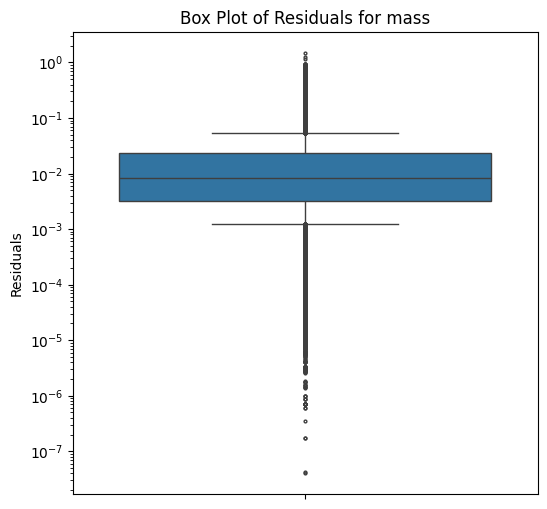

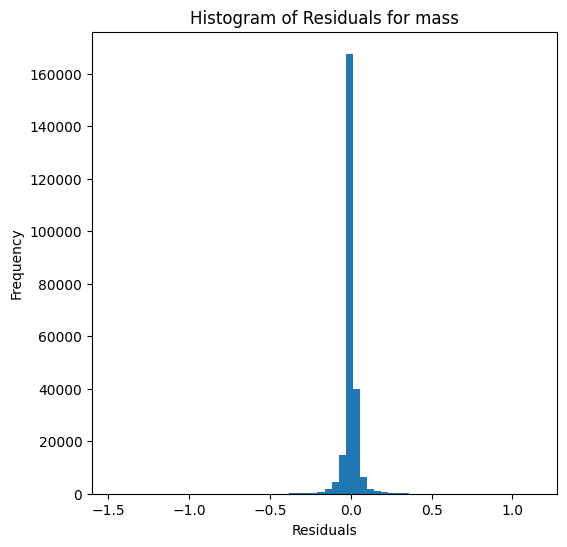

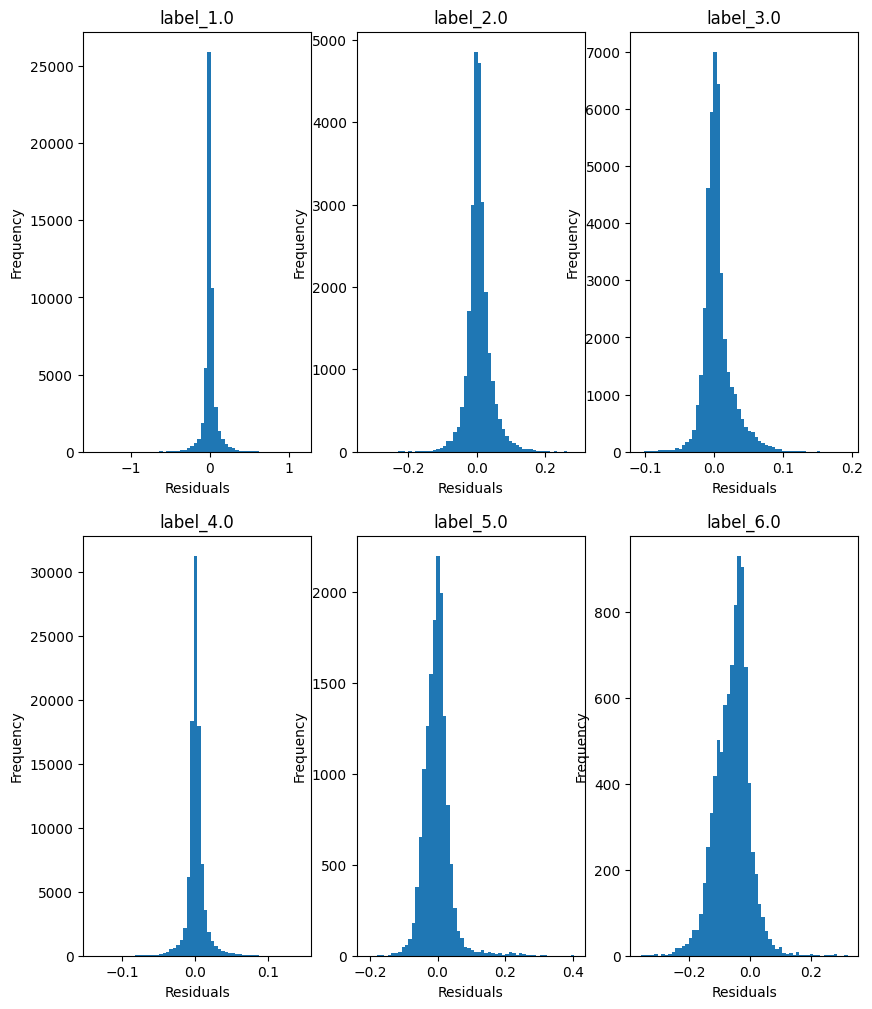

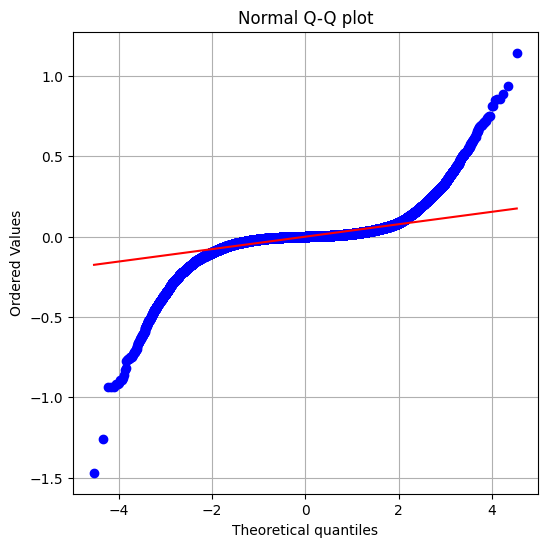

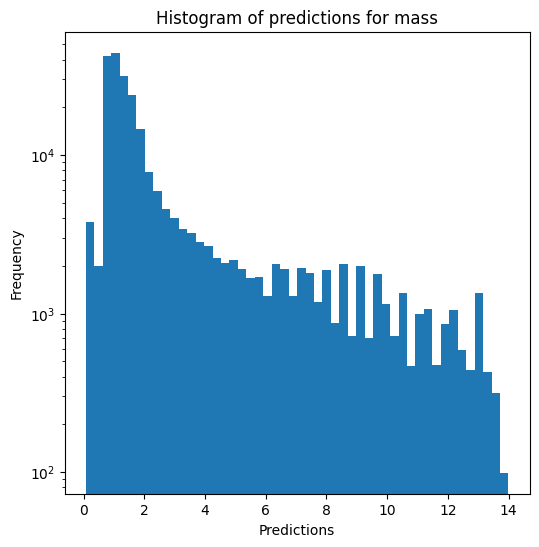

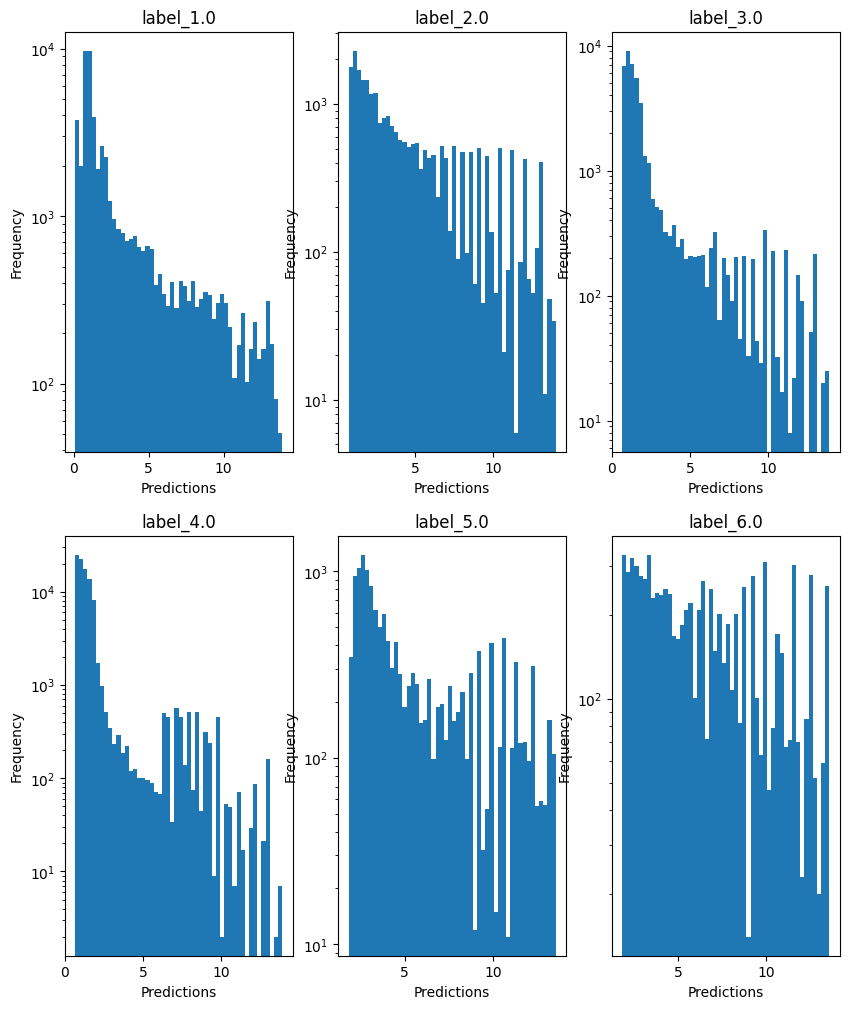

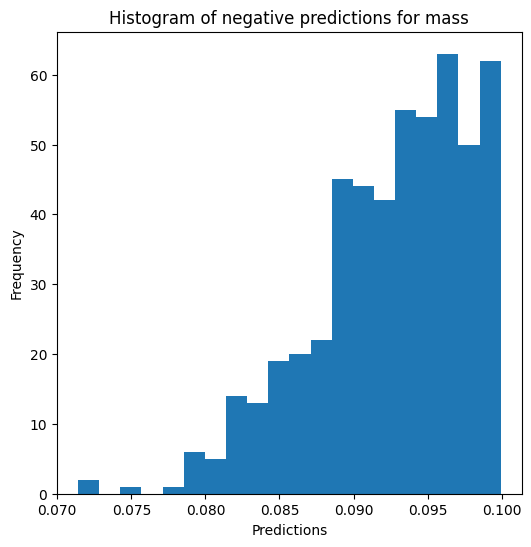


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.99924952821124
  RMSE :  0.010025829454064671
  MAE :  0.006851980137943696
  MedAE :  0.004714362388504166
  CORR :  0.9996247501188131
  MAX_ER :  0.08896295685255406
  Percentiles : 
    75th percentile :  0.009184591126604955
    90th percentile :  0.015166520496588815
    95th percentile :  0.02010547089875027
    99th percentile :  0.03502351341217506

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9994404577145701
  RMSE :  0.01284990524417628
  MAE :  0.009512662463685836
  MedAE :  0.007496822958309862
  CORR :  0.9997269256609371
  MAX_ER :  0.15352155580429705
  Percentiles : 
    75th percentile :  0.013189632936975615
    90th percentile :  0.019703675985482158
    95th percentile :  0.024772533746863855
    99th percentile :  0.03776110700516406

radius results for the 

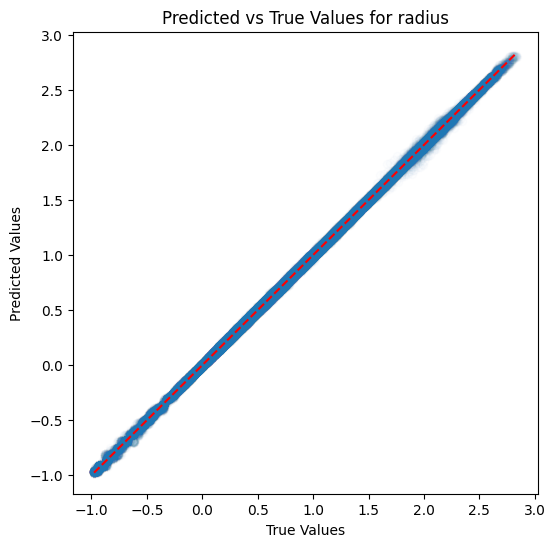

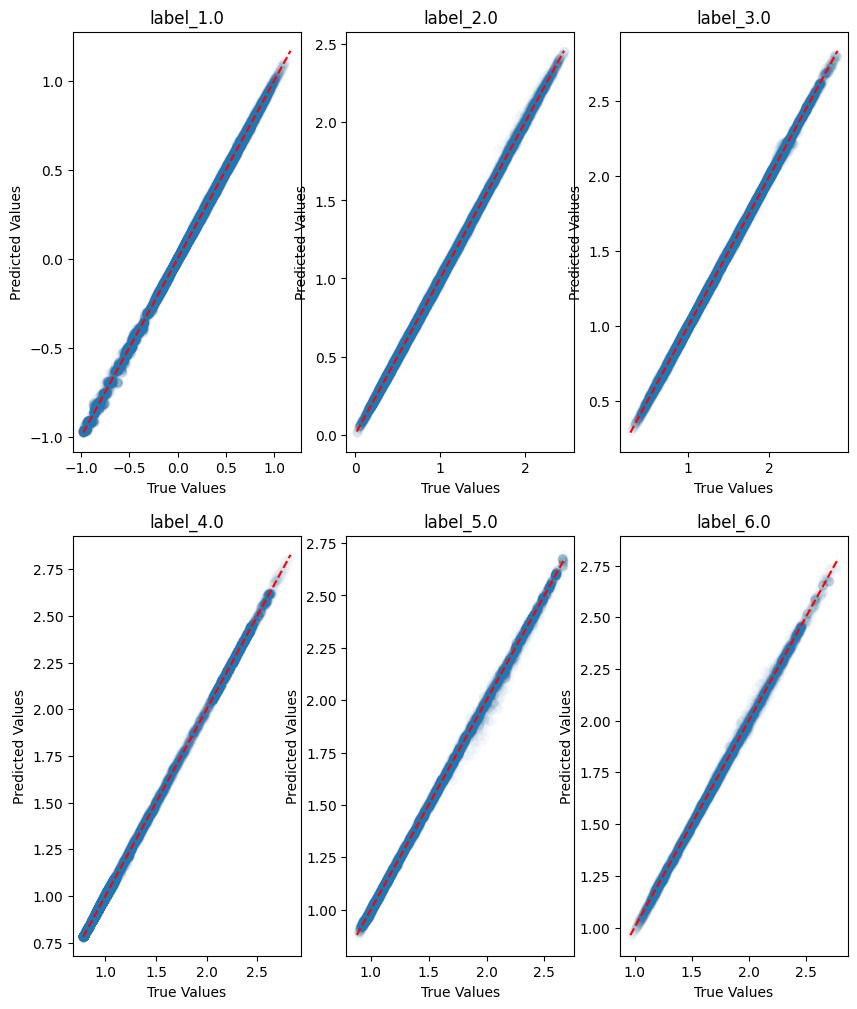

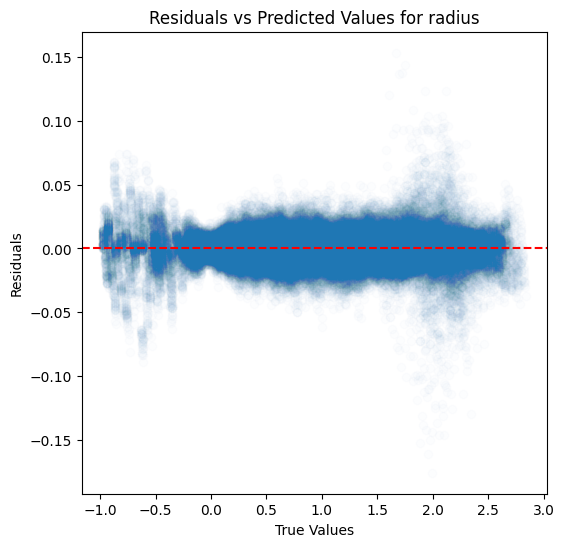

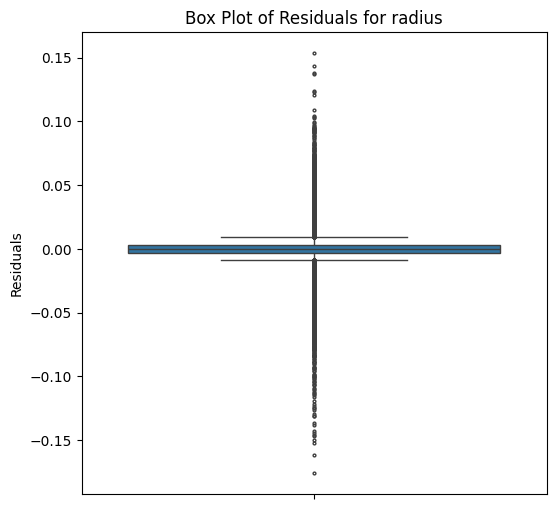

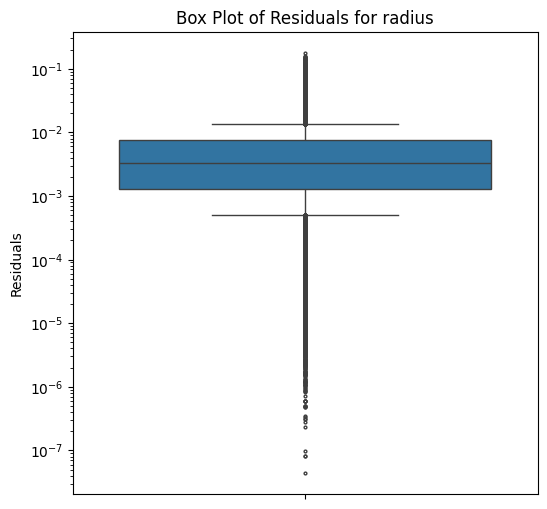

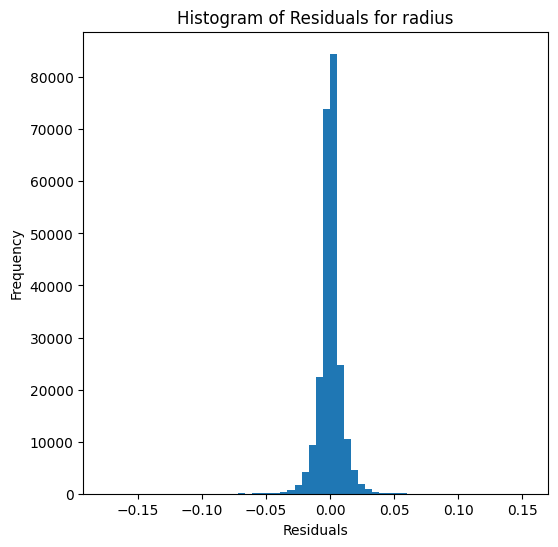

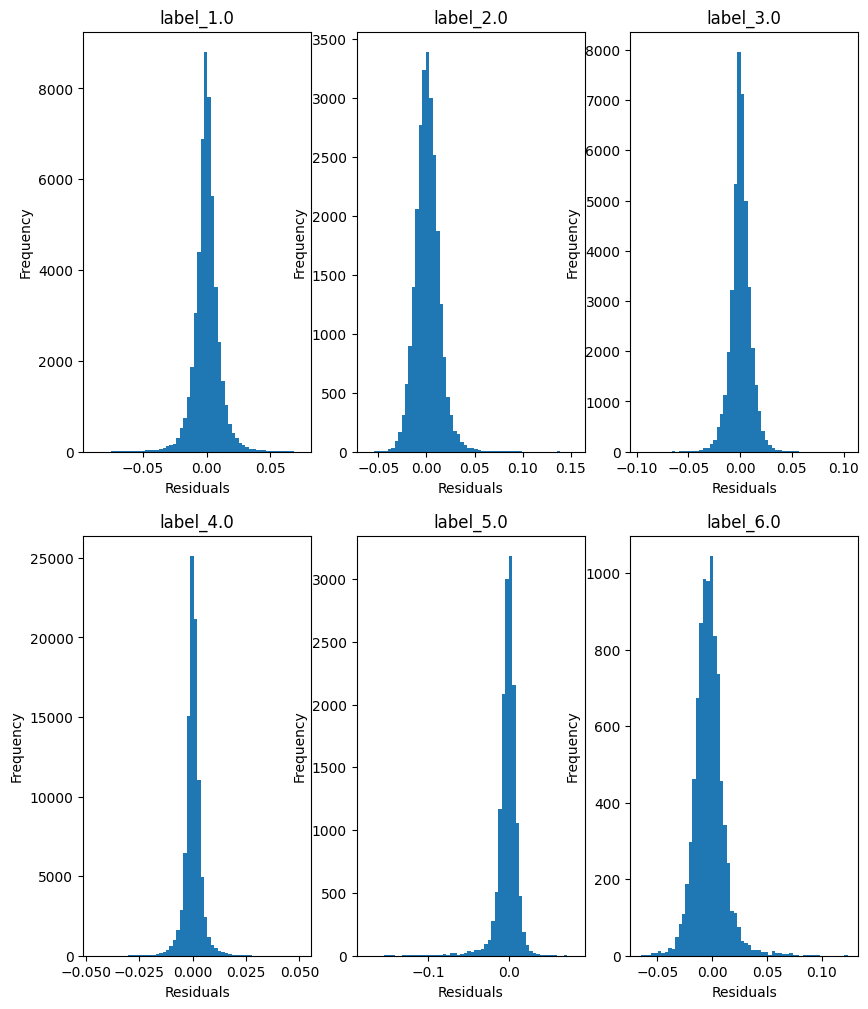

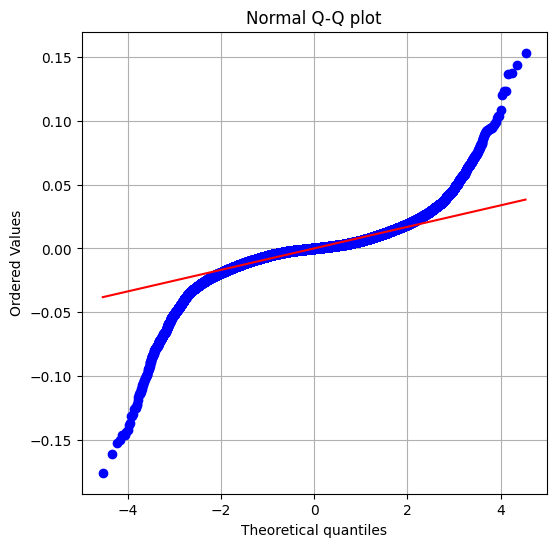

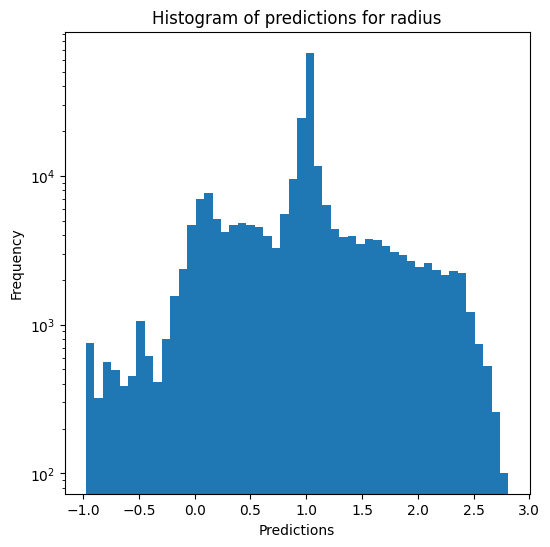

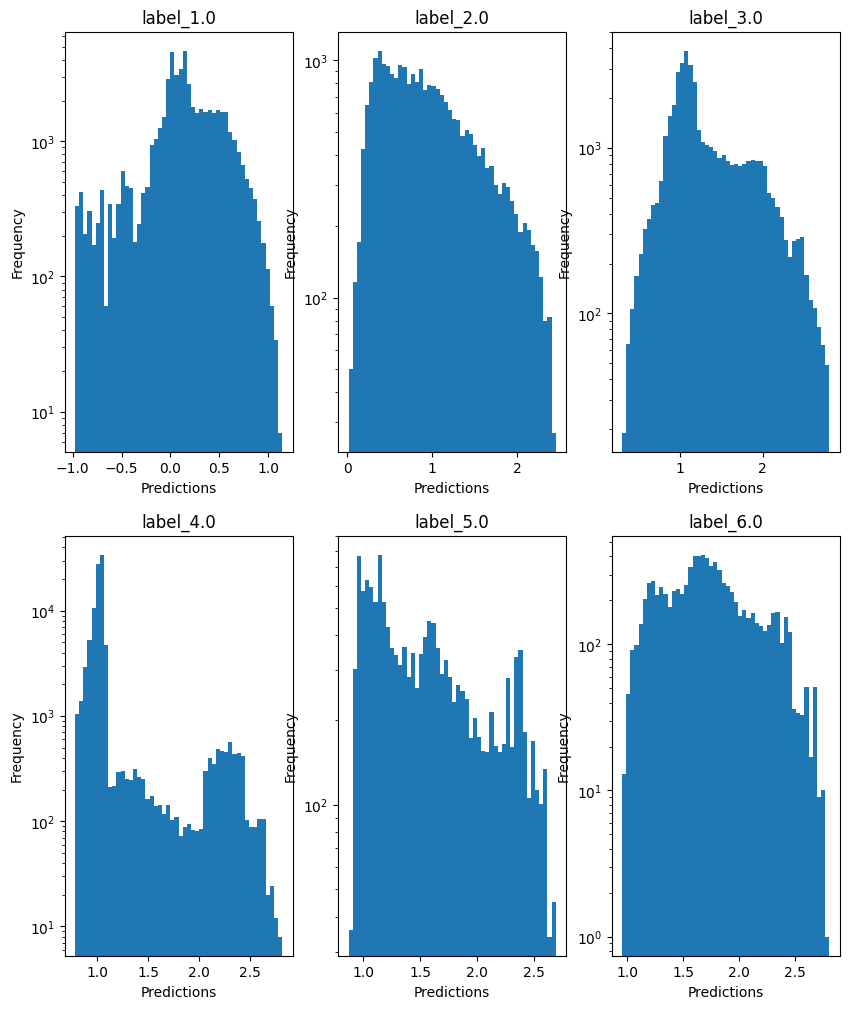

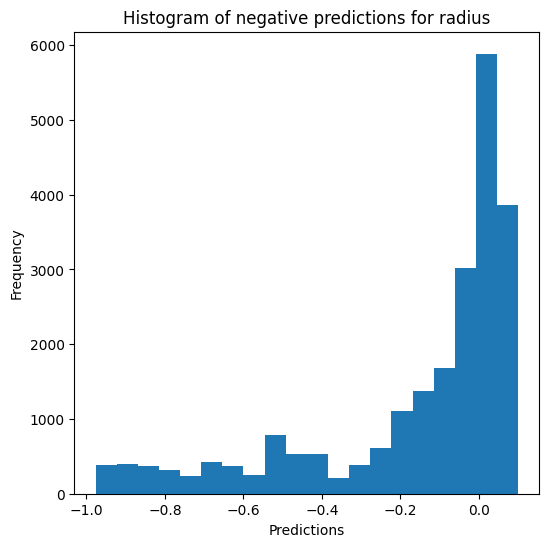

Saving predictions and results...


In [19]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)

### Multi-layer perceptron

In [20]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_standard train data :
Performing K-fold...
Split 1 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.0003872253802025748
2 0.00038744714510291636
3 0.0005680922864509964
4 0.000397812096581605
5 0.0004691942701256803

Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.999876980759126
  RMSE :  0.033471272370407305
  MAE :  0.01903375286727858
  MedAE :  0.0096790752015532
  CORR :  0.9999385371869717
  MAX_ER :  0.3922058237625077
  Percentiles : 
    75th percentile :  0.01971320845637725
    90th percentile :  0.048377485371340345
    95th percentile :  0.07631211097387092
    99th percentile :  0.13571147495393118

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9998755591637393
  RMSE :  0.037940242321201405
  MAE :  0.02421770905079834
  MedAE :  0.014815807502960077
  CORR :  0.9999438377015777
  MAX_ER :  0.29818563421065925
  Percentiles : 
    75th percentile :  0.030874154776904694
    90th percentile :  0.05519943229233544
    95th percentile :  0.0

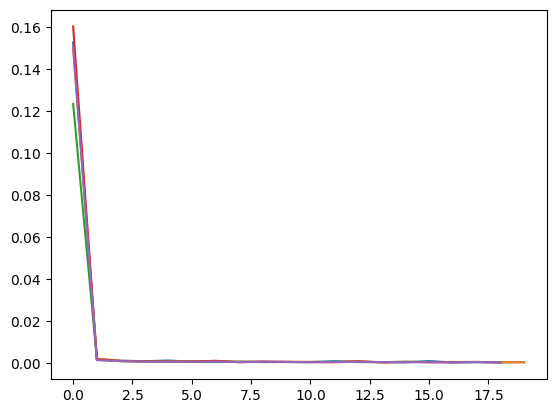

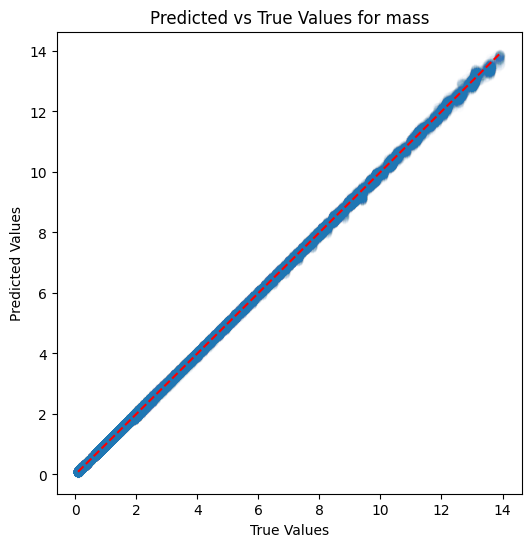

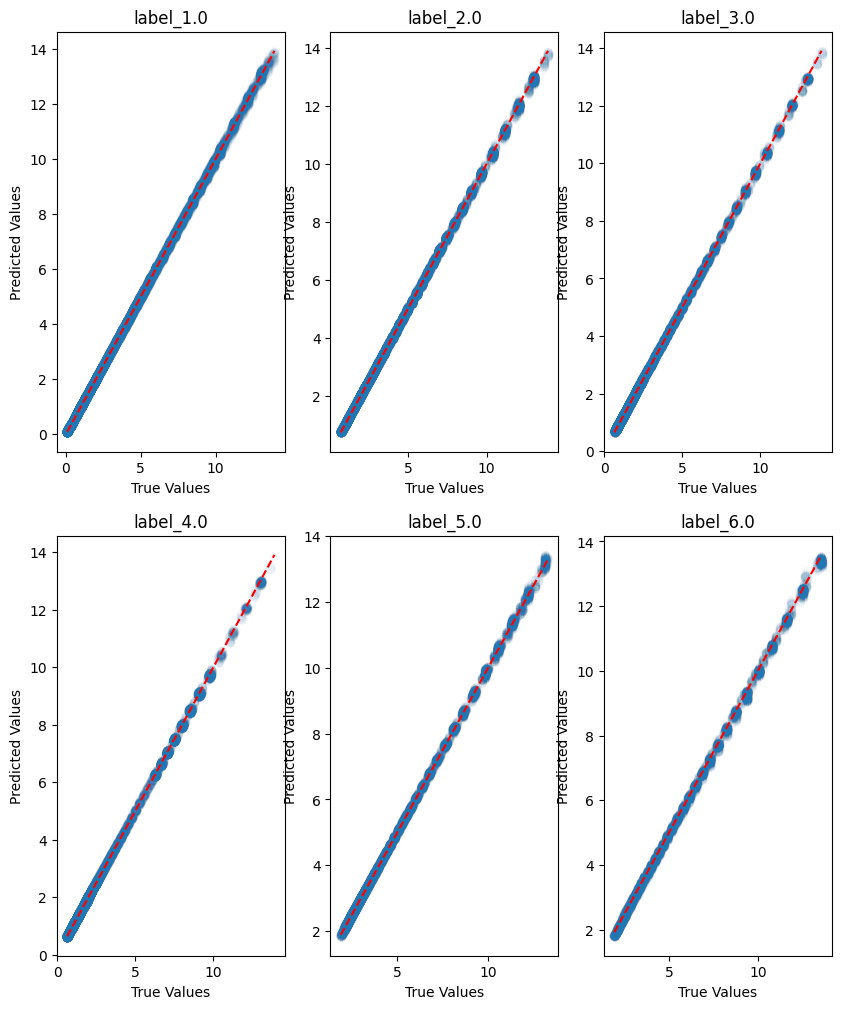

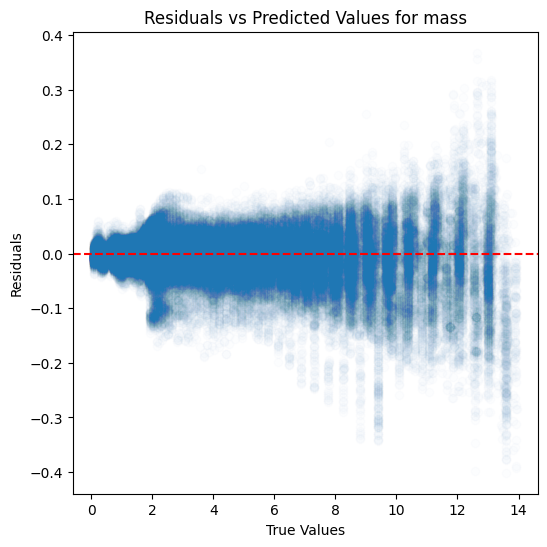

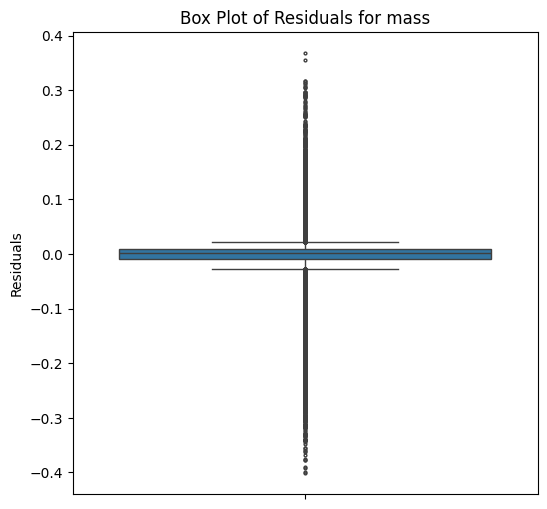

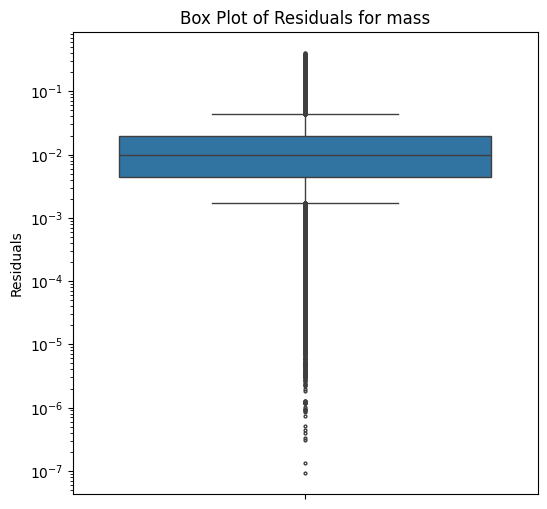

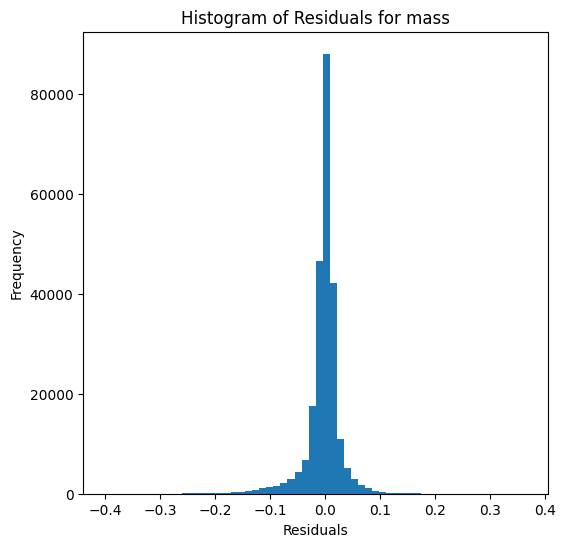

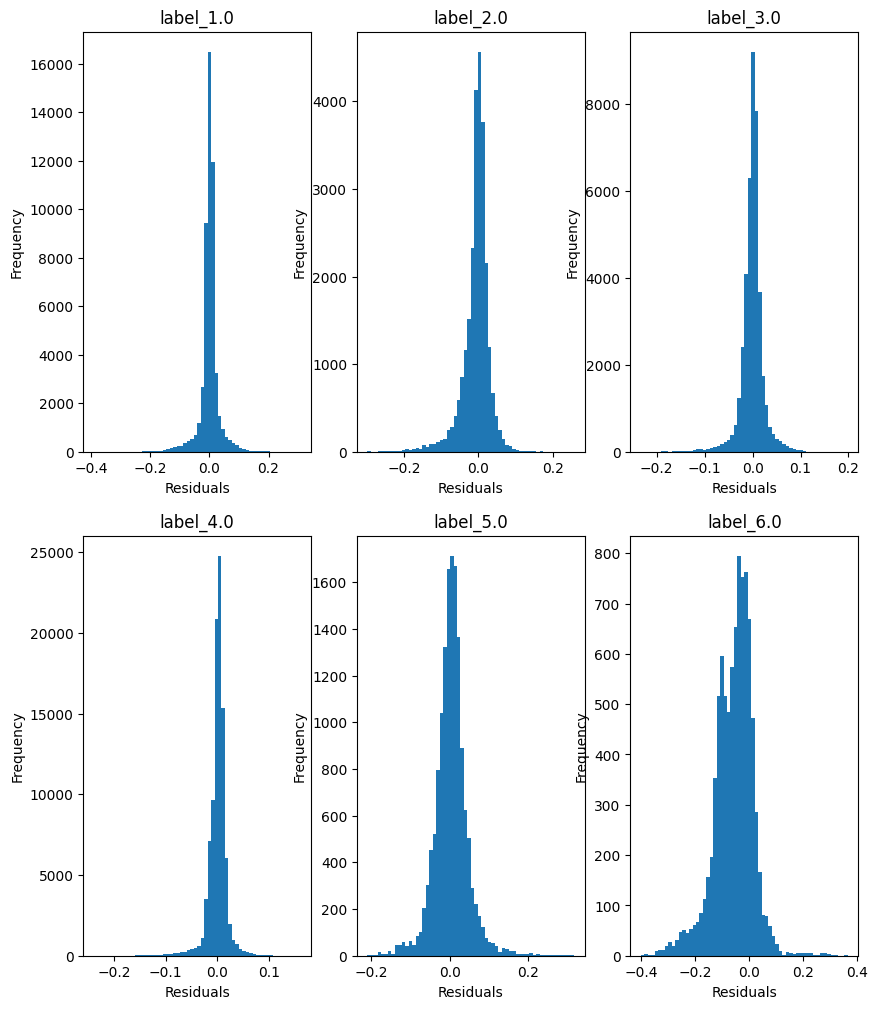

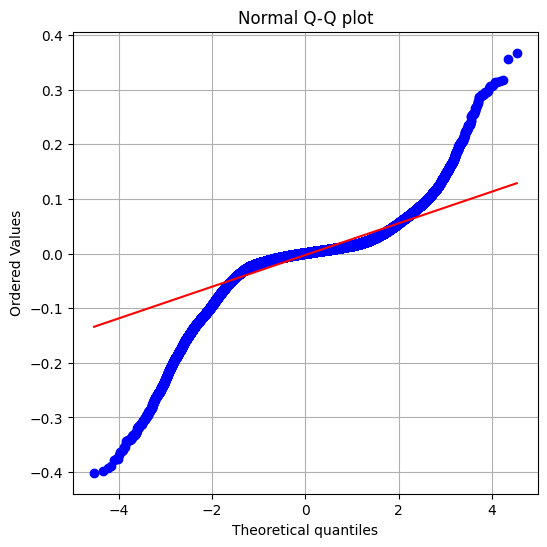

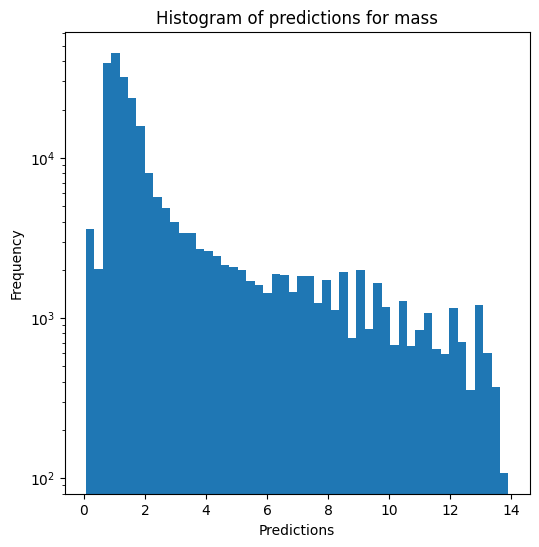

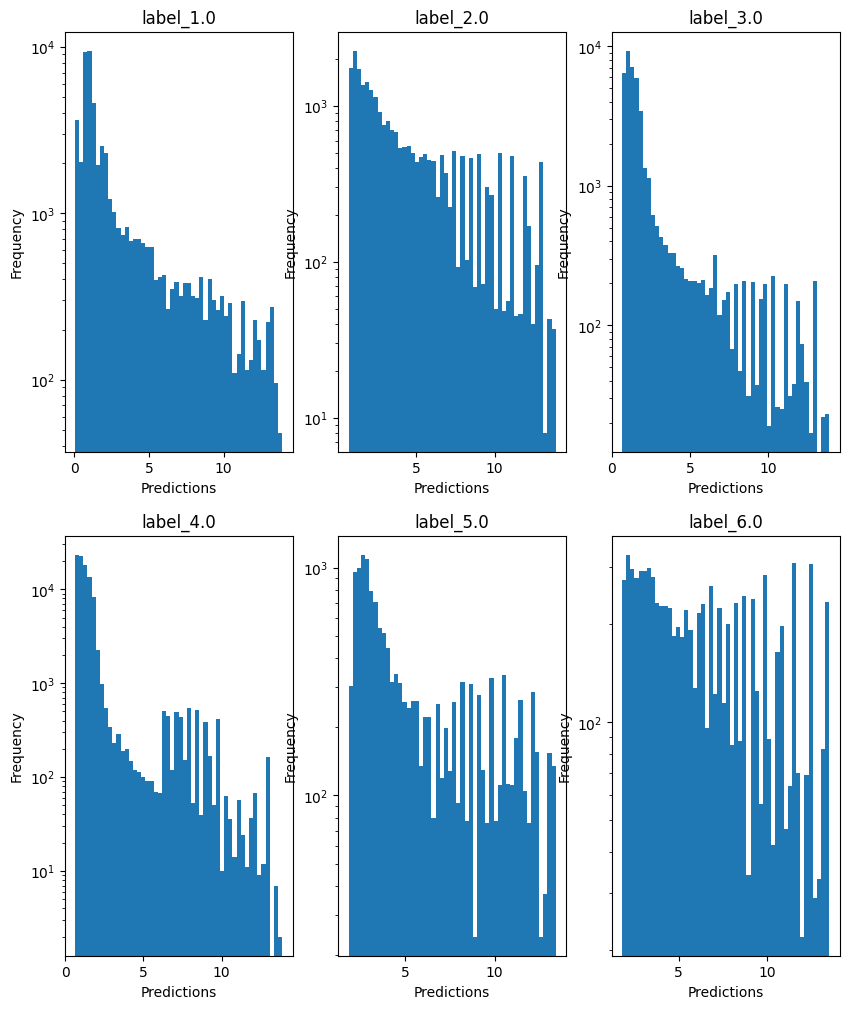

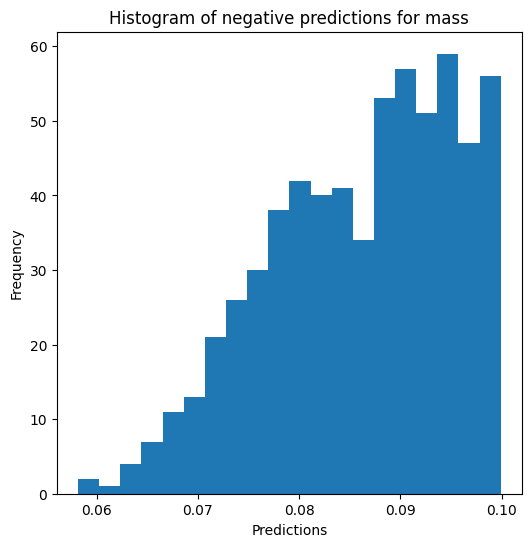


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9994865027982304
  RMSE :  0.008309264151676002
  MAE :  0.006315323855434019
  MedAE :  0.005010691519081952
  CORR :  0.99974421200907
  MAX_ER :  0.054676855123266255
  Percentiles : 
    75th percentile :  0.008662074821999837
    90th percentile :  0.01320647570371359
    95th percentile :  0.016534397535525464
    99th percentile :  0.025525293782819845

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9995978593721945
  RMSE :  0.01086511062637694
  MAE :  0.007789877234866848
  MedAE :  0.005806612189214133
  CORR :  0.9997995223235925
  MAX_ER :  0.07752525448630299
  Percentiles : 
    75th percentile :  0.010367013338713593
    90th percentile :  0.016500636677717995
    95th percentile :  0.021295349054352604
    99th percentile :  0.037753492570164554

radius results for t

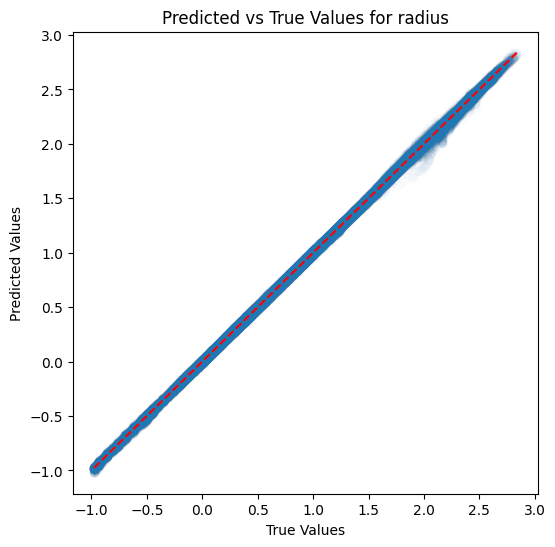

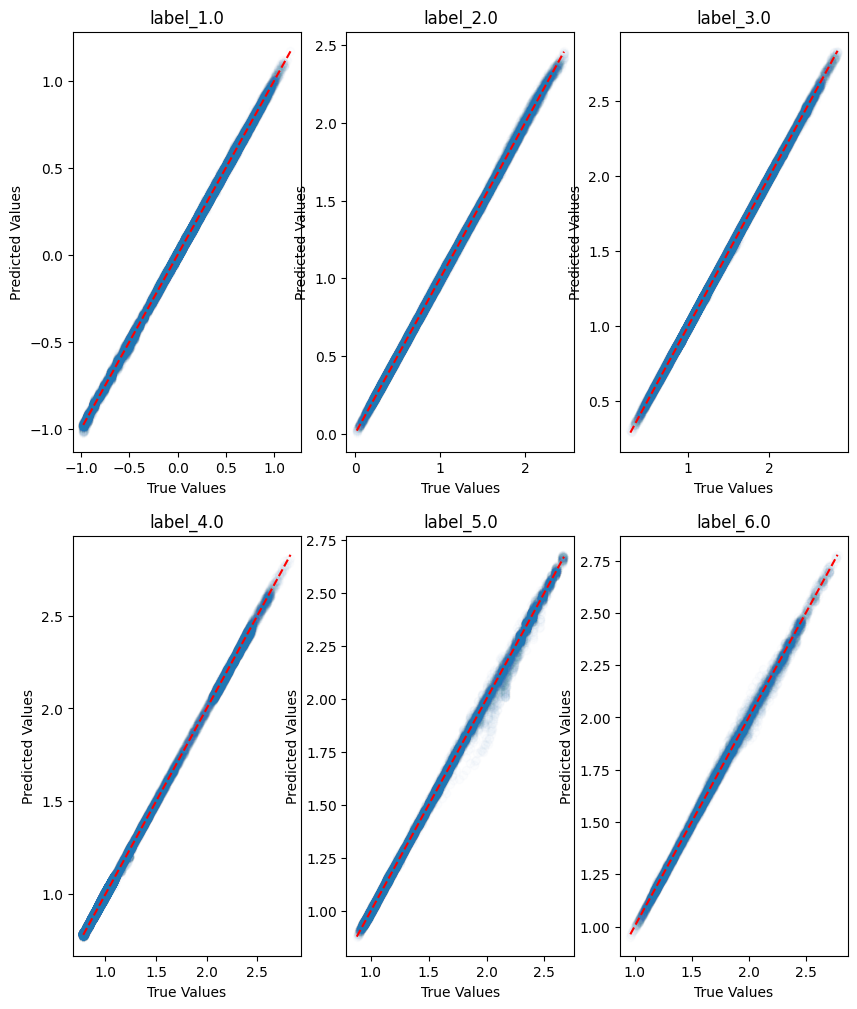

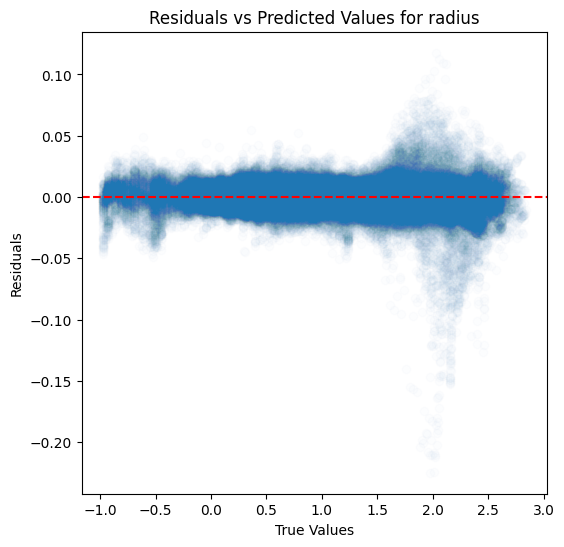

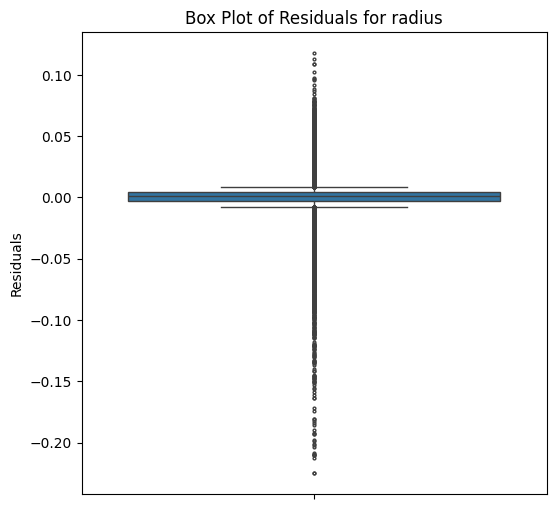

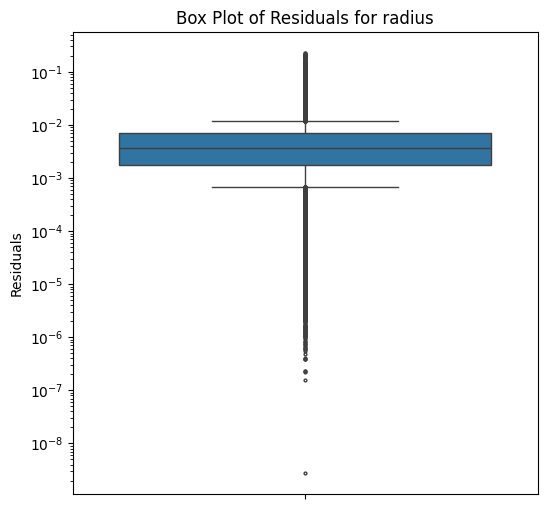

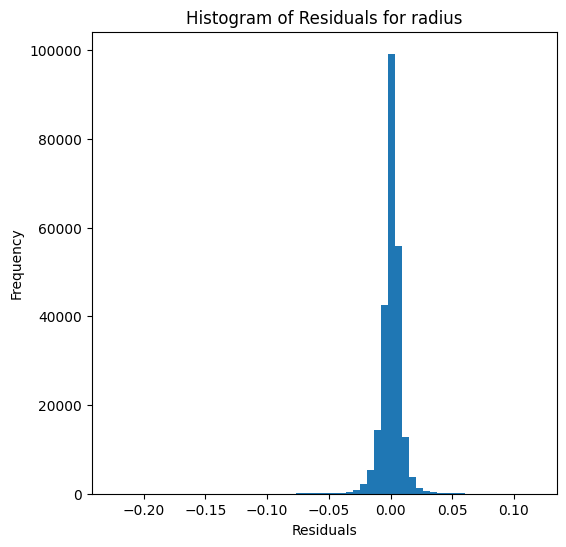

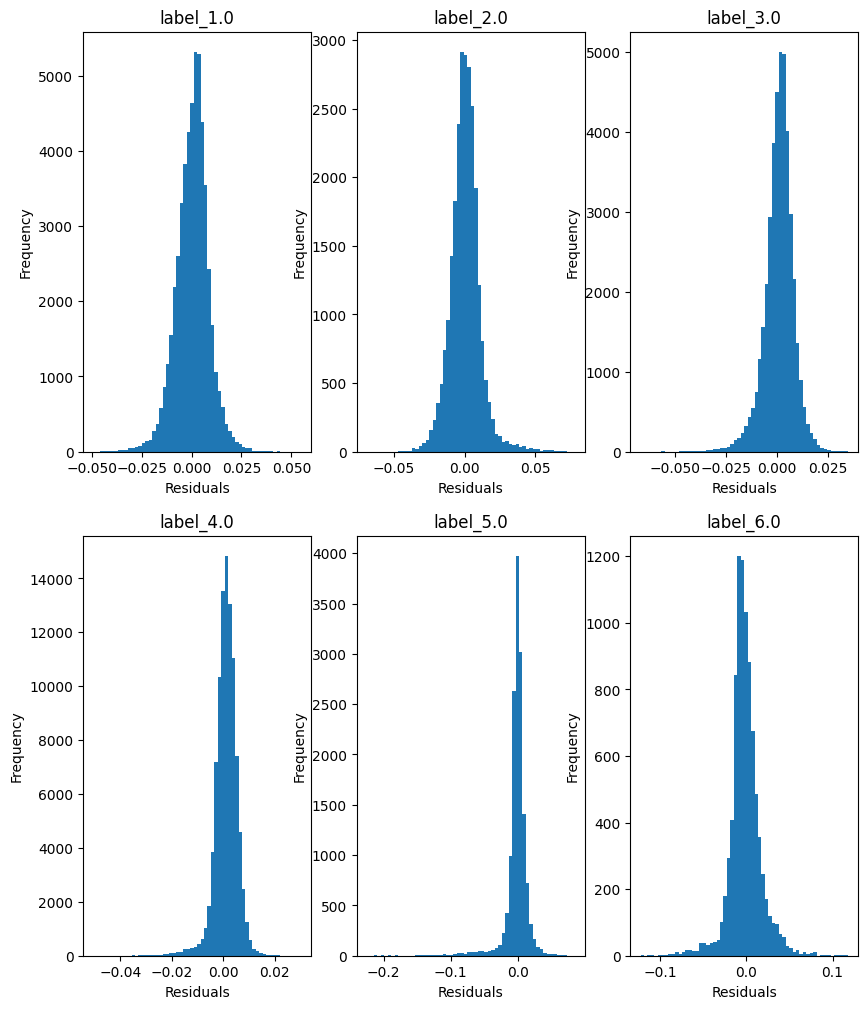

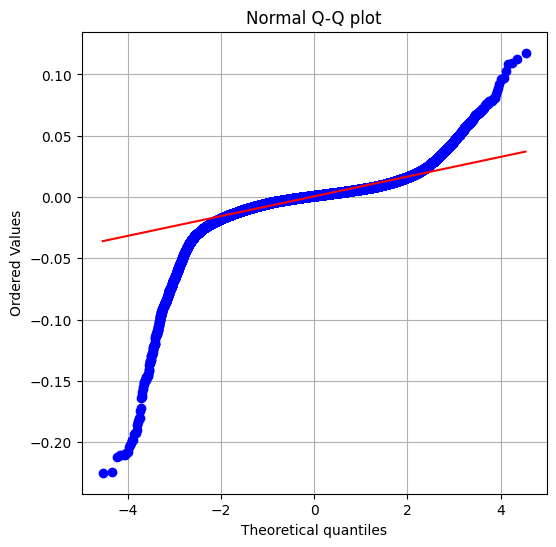

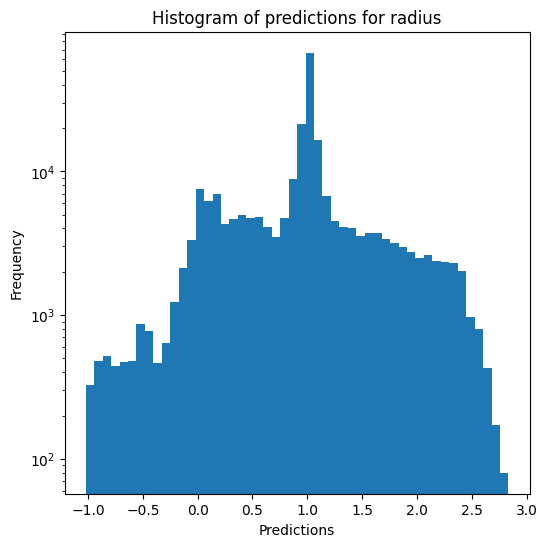

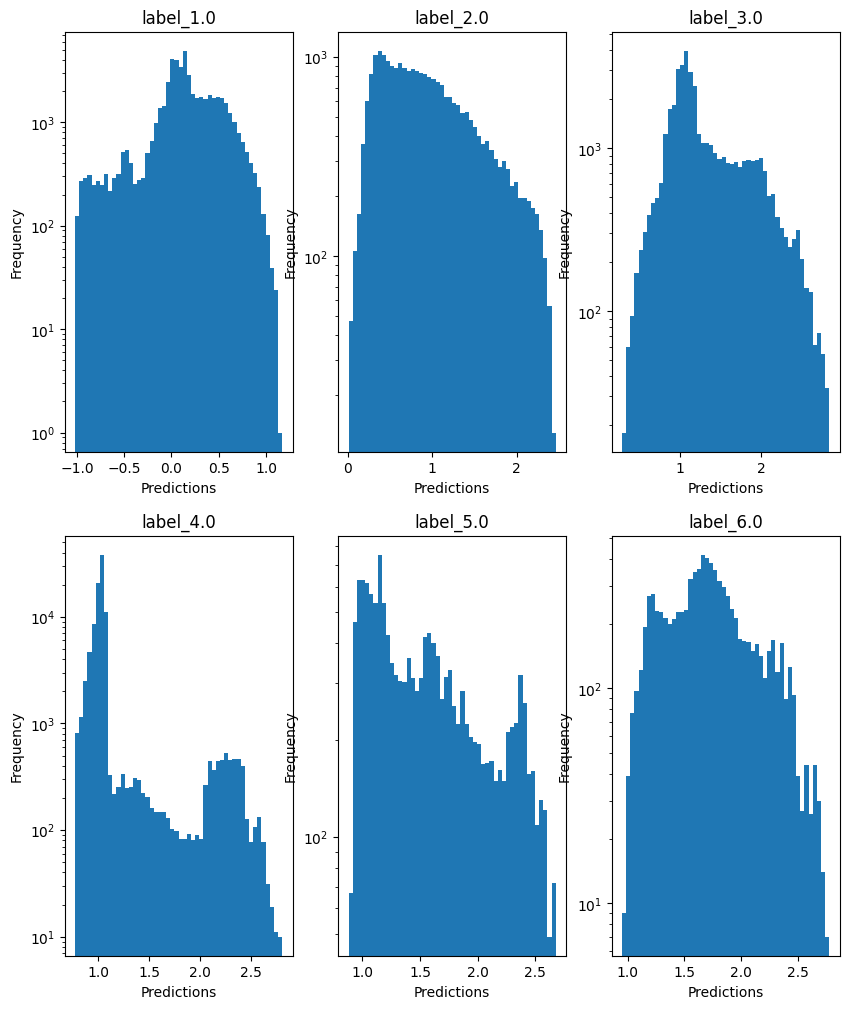

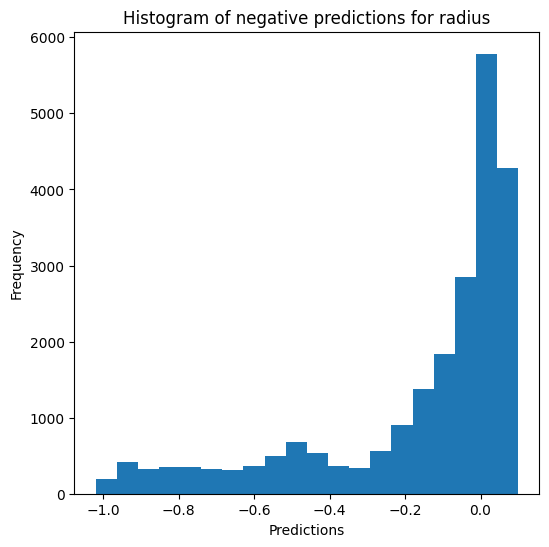

Saving predictions and results...


In [21]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, n_splits=5, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name,
                                      hidden_layer_sizes = (100, 100, 100, 100), max_iter=20, batch_size=400)

Avec batch_size=auto (200):

plus de 30 minutes pour entrainer un seul split de Kfold avec les paramètres par défaut (1 hidden layer de taille 100)

plus de 15 minutes pour entrainer un seul split de Kfold avec les 1 hidden layer de taille 10

- et max_iter=20, hidden_layer_sizes=(100, 50, 25): ~5 minutes par fold (plutôt bon résultats)
- et max_iter=20, hidden_layer_sizes=(100, 100, 100): ~5 minutes par fold

Avec batch_size=400:


Avec learning_rate= :


hidden_layer_sizes = (100, 100), max_iter=20, batch_size=200 => 17 min pour 2 splits et min_loss de 2.1
RMSE = RVE :  0.984867927459382
RMSE :  2.5335132759292107
MAE :  0.7276983504493552
MedAE :  0.3034009994265745
CORR :  0.9927285673947535
MAX_ER :  169.74348568157313
Percentiles : 75th percentile :  0.5113604728134682 90th percentile :  1.1025928446049704 95th percentile :  2.1347654852226015 99th percentile :  9.897101952249908)

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=400 => 7 min pour 2 splits et min_loss de 2.2
RVE :  0.9797171492755655
RMSE :  2.983208723004754
MAE :  0.9125599339275378
MedAE :  0.43124518658659683
CORR :  0.9920536596906272
MAX_ER :  170.53076478793002
Percentiles : 75th percentile :  0.675744507049632 90th percentile :  1.2421052024331438 95th percentile :  2.441733387262636 99th percentile :  11.925724226452427

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=800 => 3 min pour 2 splits et min_loss de 2.3 et 2.7

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=1600 => 3 min 30 pour 2 splits et min_loss de 7.8 et 3.8

=> batch_size plus grand == plus rapide mais moins bon